## Creating Lo-Fi data for small/large amplitude oscillatory shear (S/LAOS) rheometry
In this notebook, the synthetic generation of Lo-Fi data is introduced based on the given Hi-Fi data. This is a more intricate one as we need to introduce some form of physics to generate the Lo-Fi data.

First of all, we need to extract the time shift for each S/LAOS test. Note that the given data is in sheets. For each sheet, we need to extract the shifted time, maxietam strain, angular frequency, stress, strain, and strain rate, respectively, by calling the `extractor()` function.


### Importing dependencies

In [1]:
# Standard library
import os
import sys
from time import time

# Numerical / scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import odeint

# Scikit-learn core utilities
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.compose import TransformedTargetRegressor

# Scikit-learn models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor, RegressorChain

# Gaussian Processes
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

# XGBoost
import xgboost as xgb


In [2]:
np.set_printoptions(suppress=True)
file = pd.ExcelFile(r"/home/alanh/projects/PunLab/mfnn/data/processed/pig_pstat/combined_pig_pstat.py.xlsx")

df = pd.read_excel(file, sheet_name=None)
for v in df.values():
    v["Shear rate"] = v["Shear rate"] * v["Angular frequency"]
data = [
    [k, v] for k, v in df.items() 
    if (v["Oscillation strain"].iloc[0] <= 4) & (v["Oscillation strain"].iloc[0] >= 0.01)
]  # NOTE: Adjust to include different sheets

t_train, g_train, w_train = np.array([]), np.array([]), np.array([])
s_train = np.array([])

def pos_finder(vector):
    crossings = np.where((vector[:-1] < 0) & (vector[1:] >= 0))[0]
    return crossings[0] + 1 if len(crossings) > 0 else np.argmin(np.abs(vector))    # ERROR: Not finding crossings?
    
def extractor(i):
    df_sheet = data[i][1].dropna()
    print(data[i][0])

    # Convert columns to arrays
    strain_raw = df_sheet['Strain'].to_numpy()
    time_raw = df_sheet['Step time'].to_numpy()
    stress_raw = df_sheet['Stress'].to_numpy()
    sr_raw = df_sheet['Shear rate'].to_numpy()
    w_raw = df_sheet['Angular frequency'].to_numpy()
    g0_raw = df_sheet['Oscillation strain'].to_numpy() 



    # Handling the time shift
    ind = pos_finder(strain_raw)
    print(f"Start Index (zero-crossing): {ind}")

    t0 = time_raw[ind]
    
    Time_adj = time_raw[ind:] - t0  # Now strictly starts at t=0
    St = strain_raw[ind:]
    Stress = stress_raw[ind:]
    SR = sr_raw[ind:]
    w = w_raw[ind:]
    G0 = g0_raw[ind:]
    
    return Time_adj, G0, w, Stress, St, SR

### Extracting $\tau$ and $\eta$
Then, you need to run the following cell for all sheets in `Data_HF_SAOS_raw.xlsx`. For each sheet, we fit a single-mode Maxwell VE model and extract $\tau$ and $\eta$ as a function of $\gamma_0$, $\omega$, and $t$. Note that we are using the `odeint` package, which is an ODE solver. Similar to other ODE solvers, we need initial condition (`y0`), `initial_guess`, and `bounds`. For each sheet, an appropriate `y0` is needed. For this particular sheet, `y0` is 90 Pa.

For this sheet, $\tau$ and $\eta$ are 0.16183 and0.14525, respectively. We do the same thing for all stress curves to obtain the following table:

--- Processing Sheet 0: 0.628rad - 0.0264491 ---
0.628rad - 0.0264491
Start Index (zero-crossing): 0


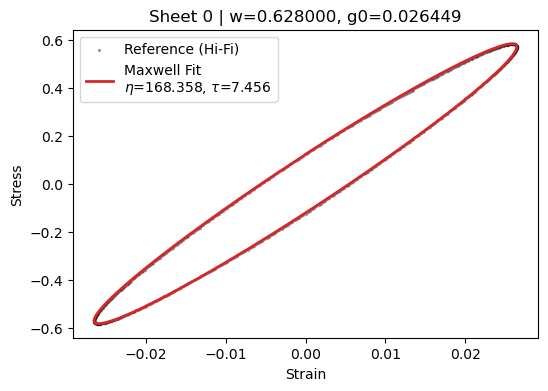

--- Processing Sheet 1: 0.628rad - 0.0909438 ---
0.628rad - 0.0909438
Start Index (zero-crossing): 0
--- Processing Sheet 2: 0.628rad - 0.2898595 ---
0.628rad - 0.2898595
Start Index (zero-crossing): 0
--- Processing Sheet 3: 0.628rad - 0.7992753 ---
0.628rad - 0.7992753
Start Index (zero-crossing): 0
--- Processing Sheet 4: 0.628rad - 0.0264054 ---
0.628rad - 0.0264054
Start Index (zero-crossing): 0
--- Processing Sheet 5: 0.628rad - 0.0906912 ---
0.628rad - 0.0906912
Start Index (zero-crossing): 0
--- Processing Sheet 6: 0.628rad - 0.2692161 ---
0.628rad - 0.2692161
Start Index (zero-crossing): 0


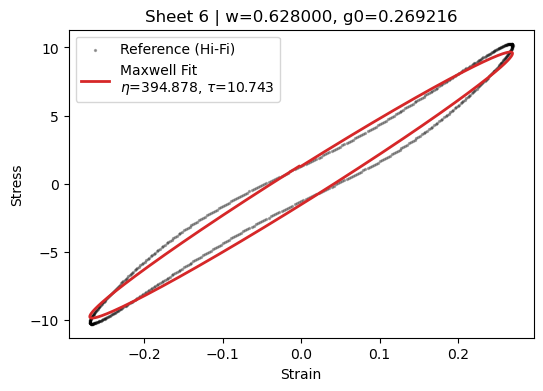

--- Processing Sheet 7: 0.628rad - 0.6953301 ---
0.628rad - 0.6953301
Start Index (zero-crossing): 0
--- Processing Sheet 8: 0.628rad - 0.0254081 ---
0.628rad - 0.0254081
Start Index (zero-crossing): 0
--- Processing Sheet 9: 0.628rad - 0.0885407 ---
0.628rad - 0.0885407
Start Index (zero-crossing): 0
--- Processing Sheet 10: 0.628rad - 0.2840398 ---
0.628rad - 0.2840398
Start Index (zero-crossing): 0
--- Processing Sheet 11: 0.628rad - 0.7656388 ---
0.628rad - 0.7656388
Start Index (zero-crossing): 0
--- Processing Sheet 12: 0.628rad - 0.0233646 ---
0.628rad - 0.0233646
Start Index (zero-crossing): 0


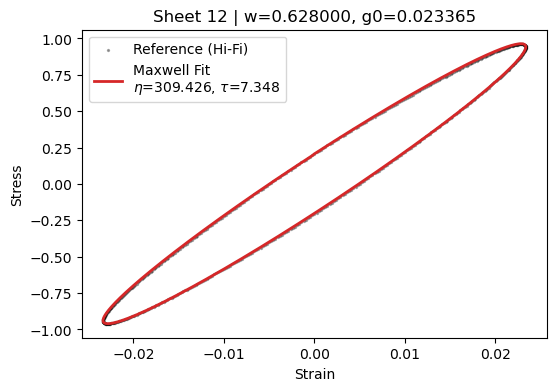

--- Processing Sheet 13: 0.628rad - 0.0854564 ---
0.628rad - 0.0854564
Start Index (zero-crossing): 0
--- Processing Sheet 14: 0.628rad - 0.2775365 ---
0.628rad - 0.2775365
Start Index (zero-crossing): 0
--- Processing Sheet 15: 0.628rad - 0.7735518 ---
0.628rad - 0.7735518
Start Index (zero-crossing): 0
--- Processing Sheet 16: 0.628rad - 0.0193767 ---
0.628rad - 0.0193767
Start Index (zero-crossing): 0
--- Processing Sheet 17: 0.628rad - 0.0790682 ---
0.628rad - 0.0790682
Start Index (zero-crossing): 0
--- Processing Sheet 18: 0.628rad - 0.2728643 ---
0.628rad - 0.2728643
Start Index (zero-crossing): 0


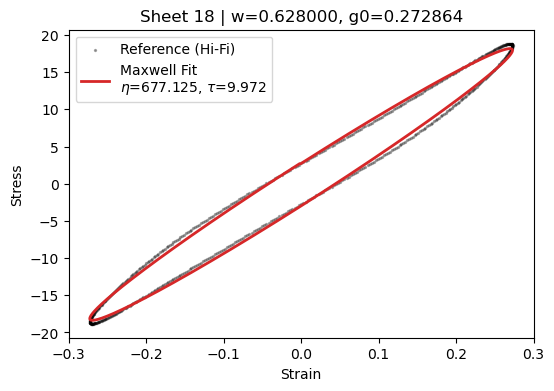

--- Processing Sheet 19: 0.628rad - 0.7652734 ---
0.628rad - 0.7652734
Start Index (zero-crossing): 0
--- Processing Sheet 20: 0.628rad - 3.2062034 ---
0.628rad - 3.2062034
Start Index (zero-crossing): 0
--- Processing Sheet 21: 0.628rad - 0.0204442 ---
0.628rad - 0.0204442
Start Index (zero-crossing): 0
--- Processing Sheet 22: 0.628rad - 0.0789863 ---
0.628rad - 0.0789863
Start Index (zero-crossing): 0
--- Processing Sheet 23: 0.628rad - 0.2703294 ---
0.628rad - 0.2703294
Start Index (zero-crossing): 0
--- Processing Sheet 24: 0.628rad - 0.7625134 ---
0.628rad - 0.7625134
Start Index (zero-crossing): 0


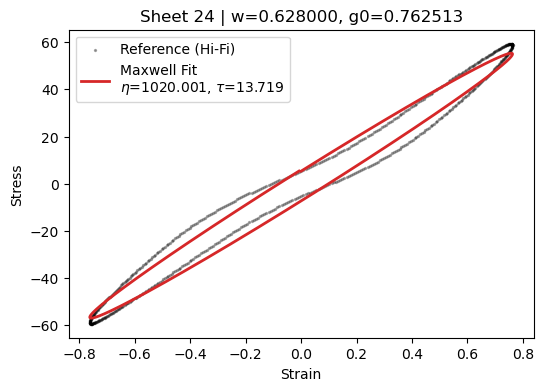

--- Processing Sheet 25: 0.628rad - 3.1766118 ---
0.628rad - 3.1766118
Start Index (zero-crossing): 0
--- Processing Sheet 26: 0.628rad - 0.0210099 ---
0.628rad - 0.0210099
Start Index (zero-crossing): 0
--- Processing Sheet 27: 0.628rad - 0.0834615 ---
0.628rad - 0.0834615
Start Index (zero-crossing): 0
--- Processing Sheet 28: 0.628rad - 0.2754981 ---
0.628rad - 0.2754981
Start Index (zero-crossing): 0
--- Processing Sheet 29: 0.628rad - 0.7561553 ---
0.628rad - 0.7561553
Start Index (zero-crossing): 0
--- Processing Sheet 30: 0.628rad - 3.4131116 ---
0.628rad - 3.4131116
Start Index (zero-crossing): 0


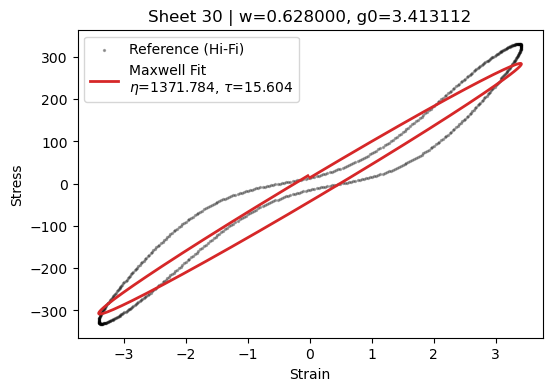

--- Processing Sheet 31: 0.628rad - 0.0201021 ---
0.628rad - 0.0201021
Start Index (zero-crossing): 0
--- Processing Sheet 32: 0.628rad - 0.0813535 ---
0.628rad - 0.0813535
Start Index (zero-crossing): 0
--- Processing Sheet 33: 0.628rad - 0.2785584 ---
0.628rad - 0.2785584
Start Index (zero-crossing): 0
--- Processing Sheet 34: 0.628rad - 0.7822665 ---
0.628rad - 0.7822665
Start Index (zero-crossing): 0
--- Processing Sheet 35: 0.628rad - 0.0249694 ---
0.628rad - 0.0249694
Start Index (zero-crossing): 0
--- Processing Sheet 36: 0.628rad - 0.088126 ---
0.628rad - 0.088126
Start Index (zero-crossing): 0


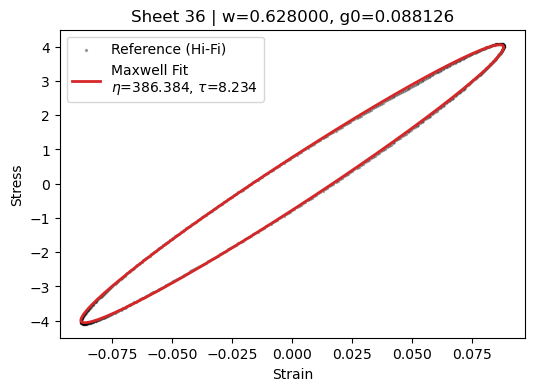

--- Processing Sheet 37: 0.628rad - 0.2777553 ---
0.628rad - 0.2777553
Start Index (zero-crossing): 0
--- Processing Sheet 38: 0.628rad - 0.7483737 ---
0.628rad - 0.7483737
Start Index (zero-crossing): 0
--- Processing Sheet 39: 0.628rad - 0.0272475 ---
0.628rad - 0.0272475
Start Index (zero-crossing): 0
--- Processing Sheet 40: 0.628rad - 0.0943436 ---
0.628rad - 0.0943436
Start Index (zero-crossing): 0
--- Processing Sheet 41: 0.628rad - 0.2934034 ---
0.628rad - 0.2934034
Start Index (zero-crossing): 0
--- Processing Sheet 42: 0.628rad - 0.8028754 ---
0.628rad - 0.8028754
Start Index (zero-crossing): 0


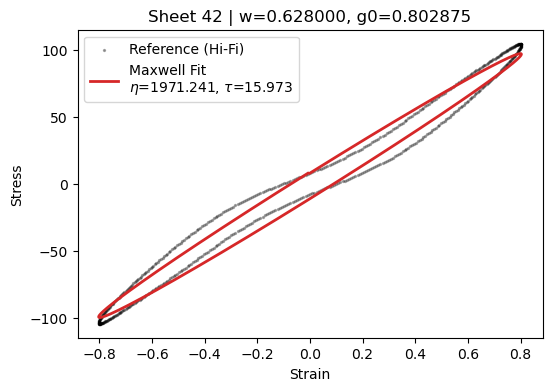

--- Processing Sheet 43: 0.628rad - 0.0202411 ---
0.628rad - 0.0202411
Start Index (zero-crossing): 0
--- Processing Sheet 44: 0.628rad - 0.0801314 ---
0.628rad - 0.0801314
Start Index (zero-crossing): 0
--- Processing Sheet 45: 0.628rad - 0.2719648 ---
0.628rad - 0.2719648
Start Index (zero-crossing): 0
--- Processing Sheet 46: 0.628rad - 0.7327955 ---
0.628rad - 0.7327955
Start Index (zero-crossing): 0

Y_fit (eta, tau):
array([[ 168.35815216,    7.4564901 ],
       [ 221.90141055,    8.03164805],
       [ 313.90990181,    9.46824104],
       [ 703.01186087,   13.73448314],
       [ 164.75685237,    7.63490881],
       [ 222.17181424,    8.35217567],
       [ 394.87781384,   10.74314004],
       [1229.94387503,   17.14103697],
       [ 148.58042325,    7.45211885],
       [ 209.45439256,    8.17339721],
       [ 313.35797374,    9.78797839],
       [ 772.88906898,   14.46664842],
       [ 309.42626038,    7.34837507],
       [ 478.98303562,    8.26556443],
       [ 785.68755277,   10

In [3]:
# ODE INT

# Initialize lists to store the results from all sheets
Y_fit_list = []
X_fit_list = []
y0_fit_list = []

# Lookup dict keyed by sheet index  # NOTE: Added this to fix lf_set array. Maybe remove list?
X_fit_dict  = {}   # sheet_idx -> [omega, g0]
Y_fit_dict  = {}   # sheet_idx -> [eta, tau]
y0_fit_dict = {}   # sheet_idx -> y0


# Define the ODE function (relies on global g0, omega, which we update in the loop)
def maxwell_ve(y, t, eta, tau, g0, omega):
    gdot = g0 * omega * np.cos(omega * t)
    dydt = (1.0 / tau) * (eta * gdot - y)
    return dydt


def fit_function(t, eta, tau, y0, g0, omega):
    y_pred = odeint(maxwell_ve, y0, t, args=(eta, tau, g0, omega))
    return y_pred[:, 0]


# Loop over all sheets
for i in range(len(data)):
    print(f"--- Processing Sheet {i}: {data[i][0]} ---")
    
    # Extract data for this specific sheet
    t_train, g_train, w_train, s_train, st_train, sr_train = extractor(i)

    # Get relevant maxwell variables
    assert len(np.unique(g_train)) == 1
    assert len(np.unique(w_train)) == 1
    g0 = np.unique(g_train)[0]
    omega = np.unique(w_train)[0]
    y0 = s_train.iloc[0] if hasattr(s_train, 'iloc') else s_train[0]
    
    # Setup fitting vectors
    t = t_train
    y = s_train
    g = g0 * np.sin(omega * t_train)  # Theoretical strain ONLY for plotting, should be fine to use st_train with SPP

    # Wrapper to freeze extra variables
    fit_wrapper = lambda t_val, eta_val, tau_val: fit_function(
        t_val, eta_val, tau_val,
        y0, g0, omega
    )

    # Make initial guess and bounds
    stress_amp = (np.max(s_train) - np.min(s_train)) / 2.0
    Gprime_est = stress_amp / g0
    eta_guess = Gprime_est / omega
    tau_guess = 1 / omega
    initial_guess = [eta_guess, tau_guess]
    
    # Perform the Fit
    bounds = ([0.0, 0.0], [np.inf, np.inf])
    try:
        fit_params, covariance = curve_fit(fit_wrapper, t, y,
                                           p0=initial_guess,
                                           bounds=bounds,
                                           method='trf',
                                           maxfev=5000)
        eta_fit, tau_fit = fit_params
    except RuntimeError:
        print(f"Fit failed for sheet {i}. Using zeros.")
        eta_fit, tau_fit = 0.0, 0.0

    # Append results
    Y_fit_list.append([eta_fit, tau_fit])   # Y_fit stores [eta, tau]
    X_fit_list.append([omega, g0])  # X_fit stores [omega, g0]
    y0_fit_list.append(y0)  # y0_fit stores the initial stress

    X_fit_dict[i]  = [omega, g0]
    Y_fit_dict[i]  = [eta_fit, tau_fit]
    y0_fit_dict[i] = y0

    # Plot
    y_predicted = fit_function(t, eta_fit, tau_fit, y0, g0, omega)
    
    if i % 6 == 0:
        plt.figure(figsize=(6, 4))
        plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
        plt.scatter(st_train, y, label='Reference (Hi-Fi)', s=2, color='k', alpha=0.3)
        plt.plot(g, y_predicted, '-', label=f'Maxwell Fit\n$\eta$={eta_fit:.3f}, $\\tau$={tau_fit:.3f}', linewidth=2, color='tab:red')
        plt.xlabel('Strain')
        plt.ylabel('Stress')
        plt.legend()
        plt.show()
        plt.close()

# Convert lists to numpy arrays for the next steps
Y_fit = np.array(Y_fit_list)
X_fit = np.array(X_fit_list)
y0_fit = np.array(y0_fit_list)

print("\nY_fit (eta, tau):")
print(repr(Y_fit))
print("\nX_fit (omega, g0):")
print(repr(X_fit))
print("\ny0_fit (initial stress):")
print(repr(y0_fit))

### Masking Hi-Fi data
Here, and depending on which stress loop we wish to omit from MFNN training, we select from `hf_set`.

In [4]:
indices = np.arange(len(X_fit))
X_all = X_fit
Y_all = Y_fit
y_00_all = y0_fit

### Regression of $\tau$ and $\eta$ on $\gamma_0$ and $\omega$

Here, we have several options to select the regression kernel. The output of this cell is the regressed $\tau$ and $\eta$ values for each kernel.

In [5]:
# QUESTION: Scale inputs as well?
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, test_size=0.1, random_state=8)

X_log = np.log(X_all)
Y_log = np.log(Y_all)
Y_log_eta = Y_log[:, 0]   # log(eta)
Y_log_tau = Y_log[:, 1]   # log(tau)

X_train_l, X_test_l, Y_train_l, Y_test_l = train_test_split(X_log, Y_log, test_size=0.2, random_state = 8)

poly_regressor = make_pipeline(PolynomialFeatures(degree=2), MultiOutputRegressor(LinearRegression()))
poly_regressor.fit(X_train_l, Y_train_l)
poly_predictions = poly_regressor.predict(X_test_l)

rf_regressor = MultiOutputRegressor(RandomForestRegressor(n_estimators=250, random_state=8))
rf_regressor.fit(X_train_l, Y_train_l)
rf_predictions = rf_regressor.predict(X_test_l)


print("\nActual parameters:")
print(Y_test_l)

print("Second-Order Polynomial Regression Predictions:")
print(poly_predictions)
print("Eta MSE: ", mean_squared_error(Y_test_l[:, 0], poly_predictions[:, 0]))
print("Tau MSE: ", mean_squared_error(Y_test_l[:, 1], poly_predictions[:, 1]))

print("\nRandom Forest Regression Predictions:")
print(rf_predictions)
print("Eta MSE: ", mean_squared_error(Y_test_l[:, 0], rf_predictions[:, 0]))
print("Tau MSE: ", mean_squared_error(Y_test_l[:, 1], rf_predictions[:, 1]))



Actual parameters:
[[6.11404061 2.07460806]
 [7.64558119 2.72105889]
 [7.50118127 2.71149266]
 [5.52549762 2.05864843]
 [7.58641866 2.77091877]
 [6.03878095 2.24986045]
 [6.00327116 2.08627226]
 [5.12609357 2.00908481]
 [5.40959791 1.9620637 ]
 [7.16595742 2.8671187 ]]
Second-Order Polynomial Regression Predictions:
[[5.89607064 2.13672512]
 [6.89011397 2.57181119]
 [6.92188106 2.58689882]
 [5.89012832 2.13437911]
 [6.93456462 2.59294026]
 [6.42246132 2.35748256]
 [5.89055595 2.13454782]
 [5.45820434 1.97434495]
 [5.34248755 1.93542472]
 [7.63680683 2.94154259]]
Eta MSE:  0.2008115505261922
Tau MSE:  0.01004369703413269

Random Forest Regression Predictions:
[[6.05537249 2.05731811]
 [7.35360363 2.75051557]
 [7.19244013 2.69687099]
 [6.05537249 2.05731811]
 [6.82147943 2.65129499]
 [6.15915934 2.34966417]
 [6.05537249 2.05731811]
 [5.34530506 2.03822881]
 [5.53808262 1.93811028]
 [7.36265231 2.78573967]]
Eta MSE:  0.11703697347912116
Tau MSE:  0.0034536858492121014


In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Matern
from sklearn.model_selection import LeaveOneOut, cross_val_score
from tqdm.auto import tqdm

X_log = np.log(X_all)
Y_log = np.log(Y_all)

# GPR for eta
kernel_eta = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0, 1.0], nu=2.5,
              length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-2,
              noise_level_bounds=(1e-5, 1e0))

kernel_tau = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0, 1.0], nu=2.5,
              length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-2,
              noise_level_bounds=(1e-5, 1e0))

gpr_eta_optimize = GaussianProcessRegressor(
    kernel=kernel_eta,
    n_restarts_optimizer=100,   # important: explore kernel hyperparameter space
    normalize_y=True,
    random_state=8
)
print("Fitting eta")
gpr_eta_optimize.fit(X_log, Y_log[:, 0])

gpr_tau_optimize = GaussianProcessRegressor(
    kernel=kernel_tau,
    n_restarts_optimizer=100,
    normalize_y=True,
    random_state=8
)
print("Fitting tau")
gpr_tau_optimize.fit(X_log, Y_log[:, 1])

print("Optimized eta kernel:", gpr_eta_optimize.kernel_)
print("Optimized tau kernel:", gpr_tau_optimize.kernel_)

gpr_eta = GaussianProcessRegressor(
    kernel=gpr_eta_optimize.kernel_,
    optimizer=None,   # important: explore kernel hyperparameter space
    normalize_y=True,
    random_state=8
)

gpr_tau = GaussianProcessRegressor(
    kernel=gpr_tau_optimize.kernel_,
    optimizer=None,
    normalize_y=True,
    random_state=8
)

hf_set = indices
loo = LeaveOneOut()
n_splits = loo.get_n_splits(X_log)


# LOO predictions with uncertainty
eta_loo_preds = np.zeros(len(Y_log))
tau_loo_preds = np.zeros(len(Y_log))
eta_loo_std   = np.zeros(len(Y_log))
tau_loo_std   = np.zeros(len(Y_log))

print("Running LOO CV")

for train_idx, test_idx in tqdm(
    loo.split(X_log),
    total=n_splits,
    desc="LOO Progress",
    leave=True):
    
    gpr_eta.fit(X_log[train_idx], Y_log[train_idx, 0])
    gpr_tau.fit(X_log[train_idx], Y_log[train_idx, 1])

    mu_e, std_e = gpr_eta.predict(X_log[test_idx], return_std=True)
    mu_t, std_t = gpr_tau.predict(X_log[test_idx], return_std=True)

    eta_loo_preds[test_idx] = mu_e
    tau_loo_preds[test_idx] = mu_t
    eta_loo_std[test_idx]   = std_e
    tau_loo_std[test_idx]   = std_t

# Refit on all data for production use
gpr_eta.fit(X_log, Y_log[:, 0])
gpr_tau.fit(X_log, Y_log[:, 1])

eta_loo_mse = np.mean((Y_log[:, 0] - eta_loo_preds) ** 2)
tau_loo_mse = np.mean((Y_log[:, 1] - tau_loo_preds) ** 2)

print(f"Eta LOO MSE (log): {(eta_loo_mse):.4f}")
print(f"Tau LOO MSE (log): {(tau_loo_mse):.4f}")
print(f"Eta LOO MSE (orig): {(np.mean((np.exp(Y_log[:,0]) - np.exp(eta_loo_preds))**2)):.4f}")
print(f"Tau LOO MSE (orig): {(np.mean((np.exp(Y_log[:,1]) - np.exp(tau_loo_preds))**2)):.4f}")

Fitting eta
Fitting tau
Optimized eta kernel: 1.06**2 * Matern(length_scale=[0.0402, 2.26], nu=2.5) + WhiteKernel(noise_level=0.22)
Optimized tau kernel: 1.04**2 * Matern(length_scale=[15.1, 0.627], nu=2.5) + WhiteKernel(noise_level=0.0195)
Running LOO CV


LOO Progress:   0%|          | 0/47 [00:00<?, ?it/s]

Eta LOO MSE (log): 0.1475
Tau LOO MSE (log): 0.0026
Eta LOO MSE (orig): 91784.0937
Tau LOO MSE (orig): 0.4554


In [7]:
print(f"{'Sheet':>5} {'g0':>10} {'omega':>8} {'eta_fit':>10} {'eta_xgb':>10} {'eta_err%':>9} "
      f"{'tau_fit':>10} {'tau_xgb':>10} {'tau_err%':>9}")
print("-" * 95)

for i in range(len(data)):
    eta_fit, tau_fit = Y_fit_dict[i]
    omega, g0 = X_fit_dict[i]
    
    X_pred_l = np.log(np.reshape([omega, g0], (1, -1)))
    eta_xgb = np.exp(gpr_eta.predict(X_pred_l)[0])
    tau_xgb = np.exp(gpr_tau.predict(X_pred_l)[0])
    
    eta_err = 100 * abs(eta_xgb - eta_fit) / (eta_fit + 1e-12)
    tau_err = 100 * abs(tau_xgb - tau_fit) / (tau_fit + 1e-12)
    
    flag = " ← LOW AMP" if g0 < 0.1 else ""
    print(f"{i:>5} {g0:>10.6f} {omega:>8.4f} {eta_fit:>10.4f} {eta_xgb:>10.4f} {eta_err:>8.1f}% "
          f"{tau_fit:>10.4f} {tau_xgb:>10.4f} {tau_err:>8.1f}%{flag}")

Sheet         g0    omega    eta_fit    eta_xgb  eta_err%    tau_fit    tau_xgb  tau_err%
-----------------------------------------------------------------------------------------------
    0   0.026449   0.6280   168.3582   238.3456     41.6%     7.4565     7.6482      2.6% ← LOW AMP
    1   0.090944   0.6280   221.9014   343.9303     55.0%     8.0316     8.2820      3.1% ← LOW AMP
    2   0.289859   0.6280   313.9099   611.8965     94.9%     9.4682    10.1273      7.0%
    3   0.799275   0.6280   703.0119  1354.0495     92.6%    13.7345    14.6305      6.5%
    4   0.026405   0.6280   164.7569   238.2652     44.6%     7.6349     7.6427      0.1% ← LOW AMP
    5   0.090691   0.6280   222.1718   343.6188     54.7%     8.3522     8.2718      1.0% ← LOW AMP
    6   0.269216   0.6280   394.8778   579.1232     46.7%    10.7431     9.9493      7.4%
    7   0.695330   0.6280  1229.9439  1241.3211      0.9%    17.1410    15.9517      6.9%
    8   0.025408   0.6280   148.5804   236.4589     59

### Hi-Fi data extraction and sampling
Since we used the raw Hi-Fi data, we need to extract those shifted Hi-Fi data and use them for MFNN training. Also, the given Hi-Fi data was too dense, and we sample every 40 of them.

In [8]:
hf_set = indices

print(f"Training on {len(hf_set)} samples. Masking {len(indices)} samples.")
print(f"Masked Indices: {indices}")

t_hf_list, g0_hf_list, w_hf_list, g_hf_list, gdot_hf_list, s_hf_list = [], [], [], [], [], []

for i in hf_set:
    t_hf, g0_hf, w_hf, s_hf, st_hf, sr_hf = extractor(i)

    idx = np.arange(0, len(t_hf), 20)  # QUESTION: Changed from 40 to 20
    
    g0_hf_list.append(g0_hf[idx])
    t_hf_list.append(t_hf[idx])
    w_hf_list.append(w_hf[idx])
    
    g_hf_list.append(st_hf[idx])
    gdot_hf_list.append(sr_hf[idx])
    s_hf_list.append(s_hf[idx])


t_hf_sampled = np.concatenate(t_hf_list)
g0_hf_sampled = np.concatenate(g0_hf_list)
w_hf_sampled = np.concatenate(w_hf_list)
g_hf_sampled = np.concatenate(g_hf_list)
gdot_hf_sampled = np.concatenate(gdot_hf_list)
s_hf_sampled = np.concatenate(s_hf_list)

print(f"Final sampled data points: {len(s_hf_sampled)}")

Training on 47 samples. Masking 47 samples.
Masked Indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]
0.628rad - 0.0264491
Start Index (zero-crossing): 0
0.628rad - 0.0909438
Start Index (zero-crossing): 0
0.628rad - 0.2898595
Start Index (zero-crossing): 0
0.628rad - 0.7992753
Start Index (zero-crossing): 0
0.628rad - 0.0264054
Start Index (zero-crossing): 0
0.628rad - 0.0906912
Start Index (zero-crossing): 0
0.628rad - 0.2692161
Start Index (zero-crossing): 0
0.628rad - 0.6953301
Start Index (zero-crossing): 0
0.628rad - 0.0254081
Start Index (zero-crossing): 0
0.628rad - 0.0885407
Start Index (zero-crossing): 0
0.628rad - 0.2840398
Start Index (zero-crossing): 0
0.628rad - 0.7656388
Start Index (zero-crossing): 0
0.628rad - 0.0233646
Start Index (zero-crossing): 0
0.628rad - 0.0854564
Start Index (zero-crossing): 0
0.628rad - 0.2775365
Start Index (zero-crossing): 0
0.628rad - 0.773

Almost there. Now, for each set in `lf_set`, which is essentially all the loops, we call the `fit_function()` function, which predicts the linear VE stress response as a function of `t_pred`, `eta_pred`, and `tau_pred`. We then append every variable to an empty vector, and call that our Lo-Fi data. Keeping an eye on the top image as reference can also help. :)

0.628rad - 0.0264491
Start Index (zero-crossing): 0


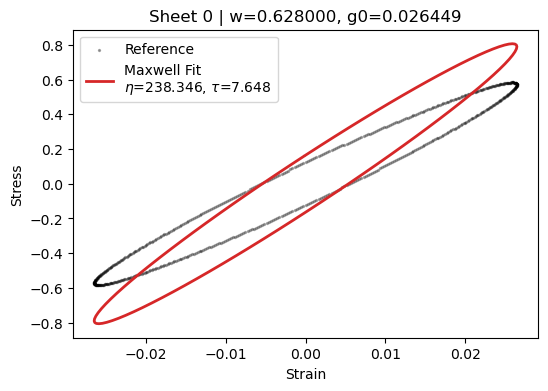

0.628rad - 0.0909438
Start Index (zero-crossing): 0


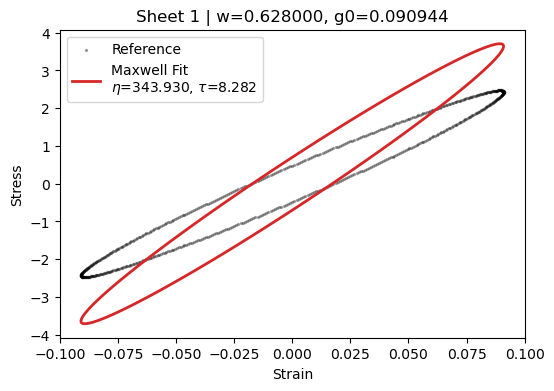

0.628rad - 0.2898595
Start Index (zero-crossing): 0


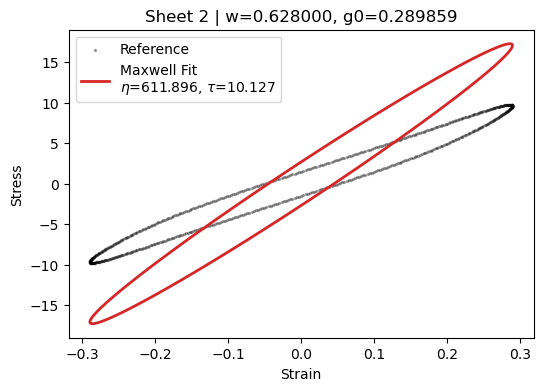

0.628rad - 0.7992753
Start Index (zero-crossing): 0


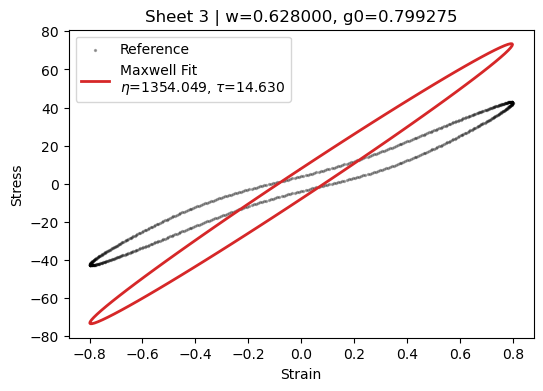

0.628rad - 0.0264054
Start Index (zero-crossing): 0


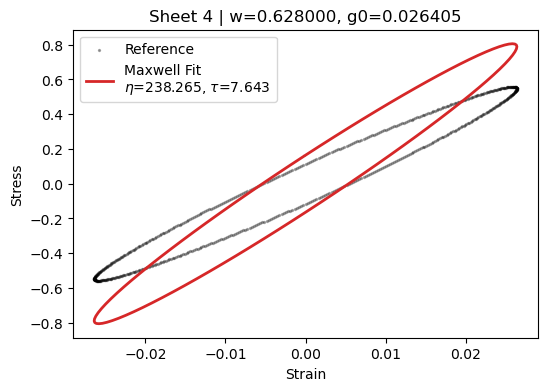

0.628rad - 0.0906912
Start Index (zero-crossing): 0


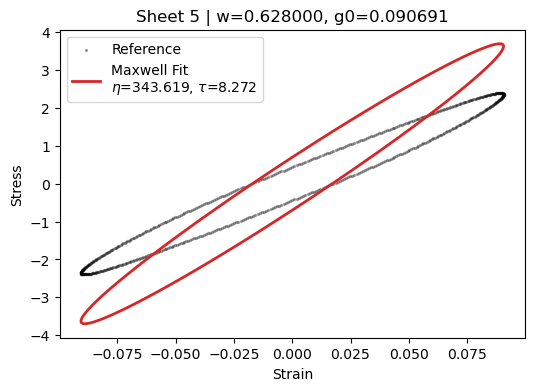

0.628rad - 0.2692161
Start Index (zero-crossing): 0


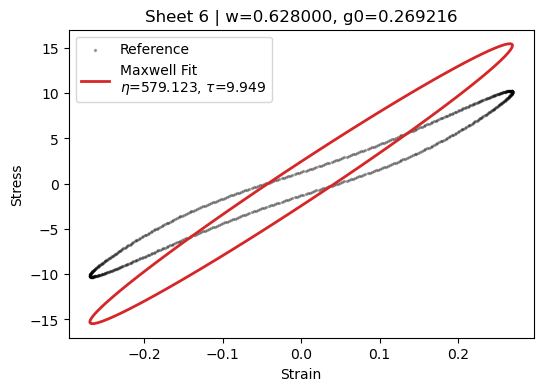

0.628rad - 0.6953301
Start Index (zero-crossing): 0


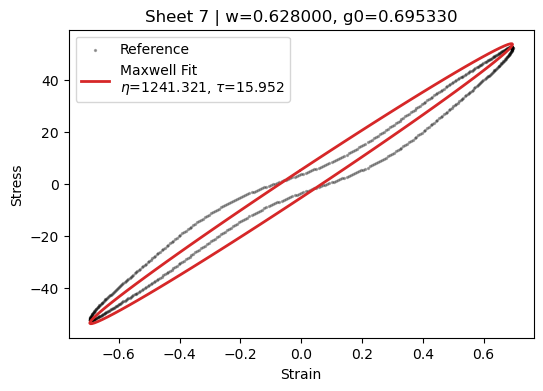

0.628rad - 0.0254081
Start Index (zero-crossing): 0


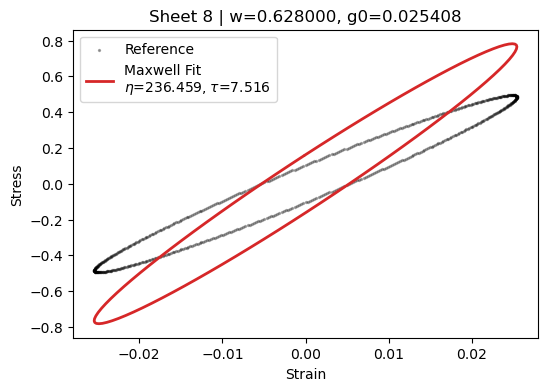

0.628rad - 0.0885407
Start Index (zero-crossing): 0


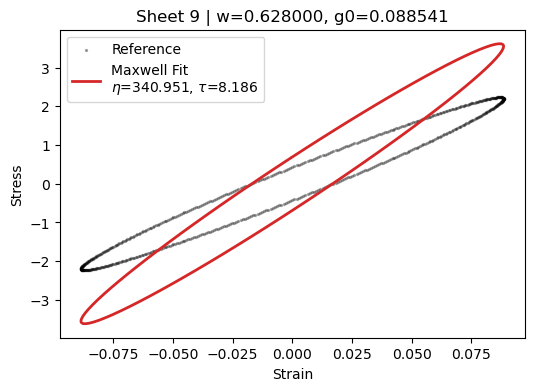

0.628rad - 0.2840398
Start Index (zero-crossing): 0


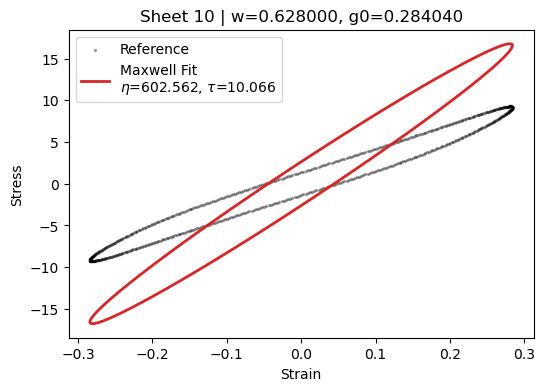

0.628rad - 0.7656388
Start Index (zero-crossing): 0


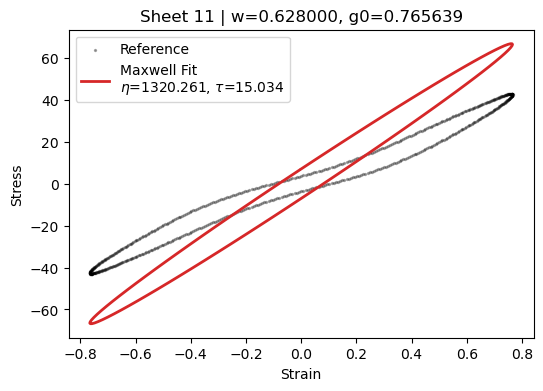

0.628rad - 0.0233646
Start Index (zero-crossing): 0


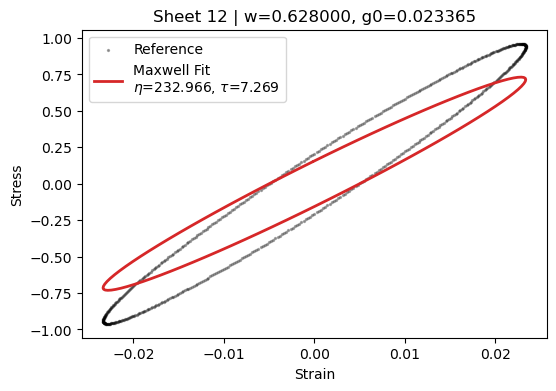

0.628rad - 0.0854564
Start Index (zero-crossing): 0


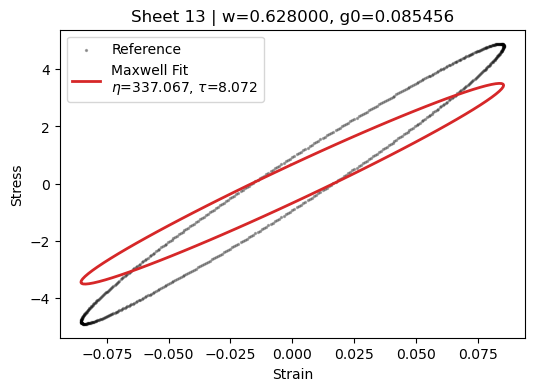

0.628rad - 0.2775365
Start Index (zero-crossing): 0


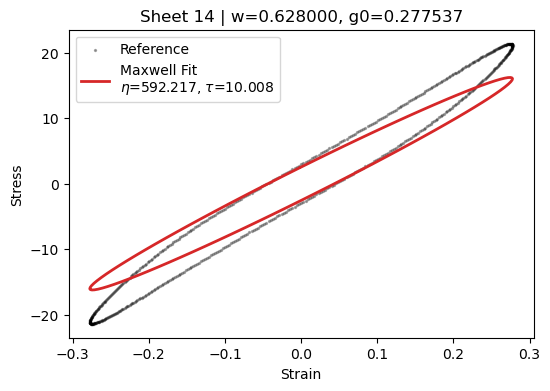

0.628rad - 0.7735518
Start Index (zero-crossing): 0


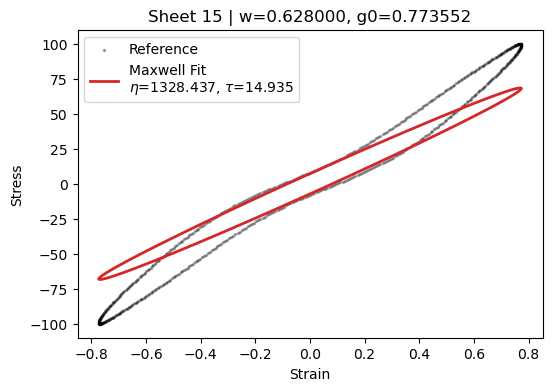

0.628rad - 0.0193767
Start Index (zero-crossing): 0


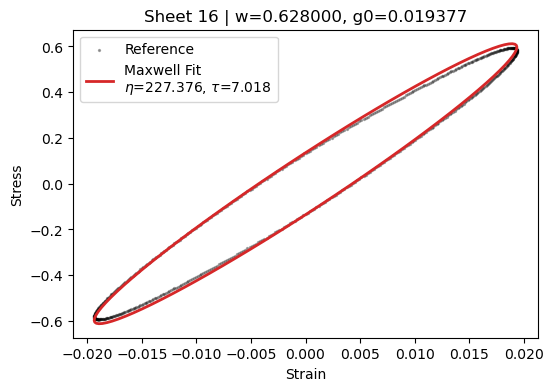

0.628rad - 0.0790682
Start Index (zero-crossing): 0


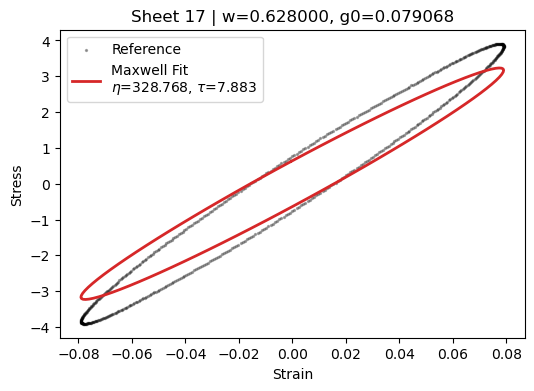

0.628rad - 0.2728643
Start Index (zero-crossing): 0


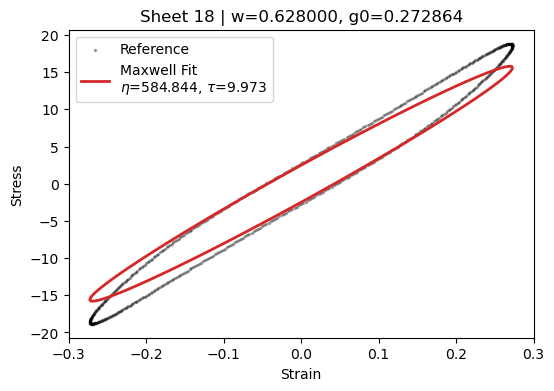

0.628rad - 0.7652734
Start Index (zero-crossing): 0


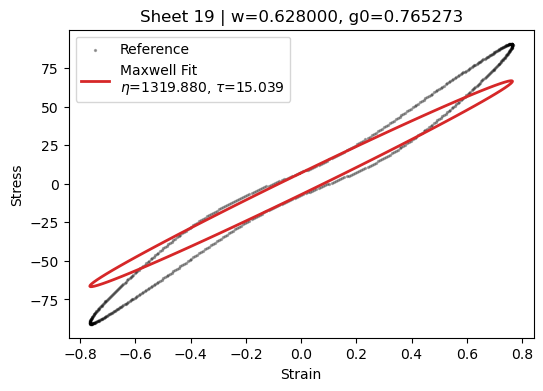

0.628rad - 3.2062034
Start Index (zero-crossing): 0


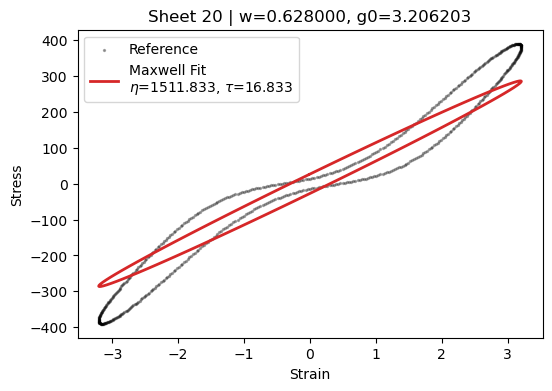

0.628rad - 0.0204442
Start Index (zero-crossing): 0


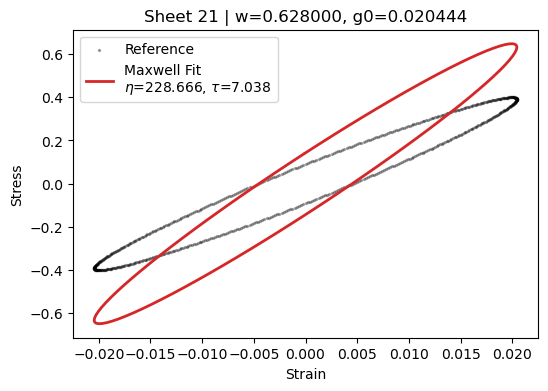

0.628rad - 0.0789863
Start Index (zero-crossing): 0


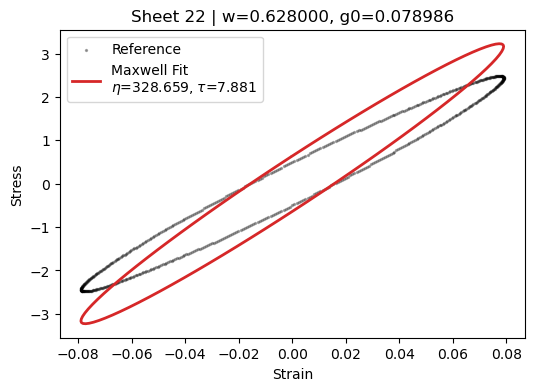

0.628rad - 0.2703294
Start Index (zero-crossing): 0


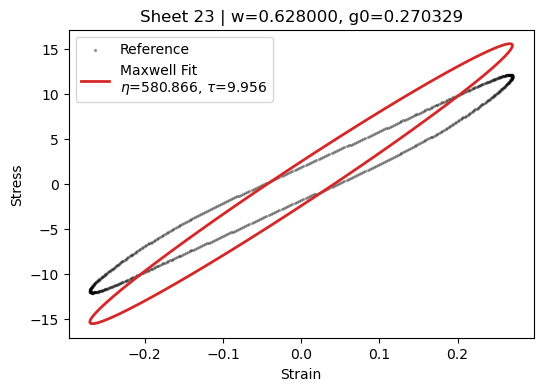

0.628rad - 0.7625134
Start Index (zero-crossing): 0


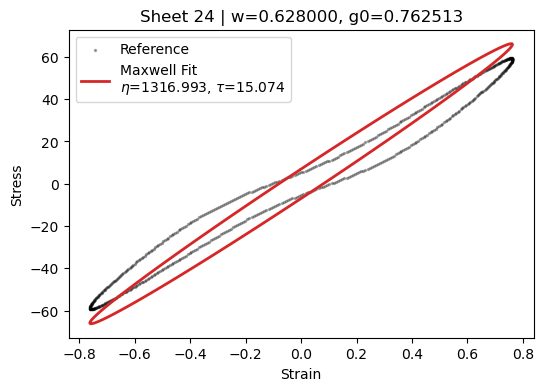

0.628rad - 3.1766118
Start Index (zero-crossing): 0


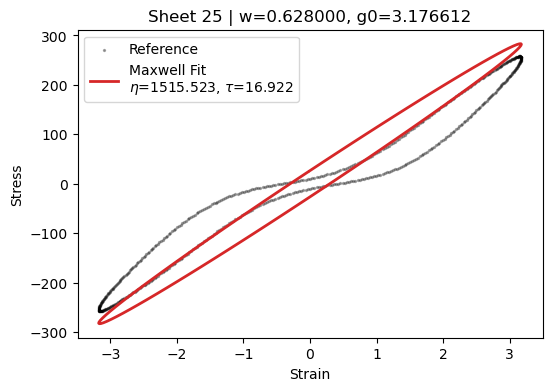

0.628rad - 0.0210099
Start Index (zero-crossing): 0


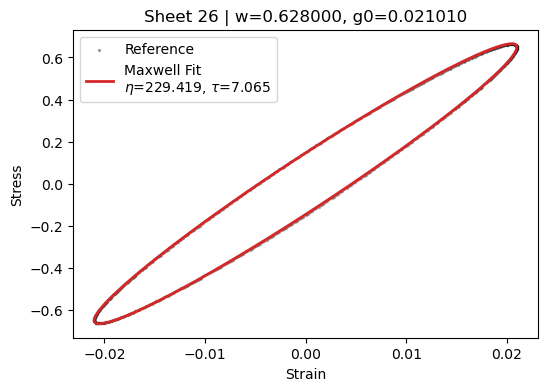

0.628rad - 0.0834615
Start Index (zero-crossing): 0


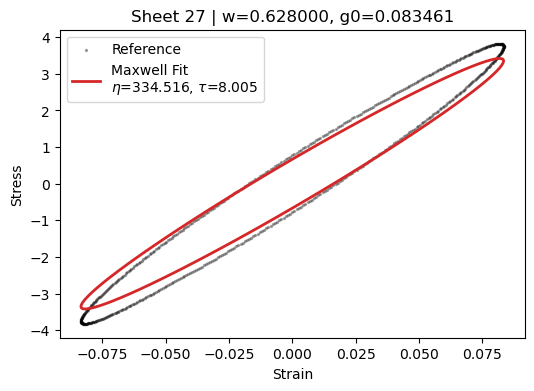

0.628rad - 0.2754981
Start Index (zero-crossing): 0


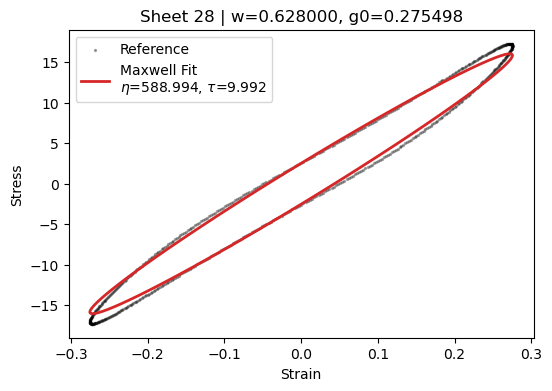

0.628rad - 0.7561553
Start Index (zero-crossing): 0


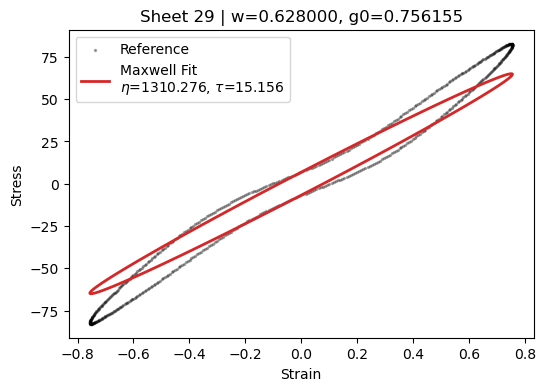

0.628rad - 3.4131116
Start Index (zero-crossing): 0


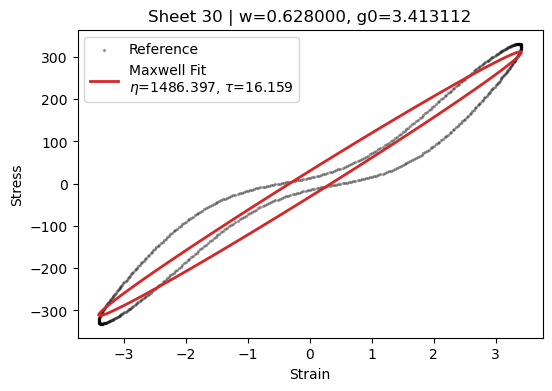

0.628rad - 0.0201021
Start Index (zero-crossing): 0


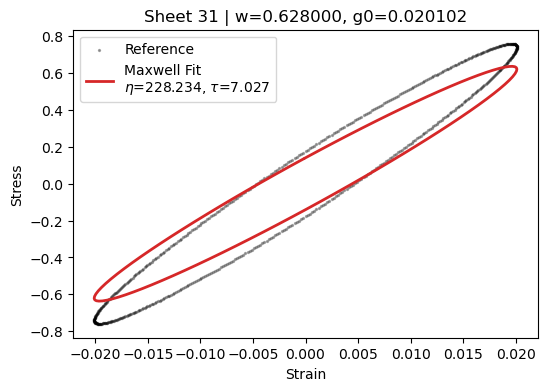

0.628rad - 0.0813535
Start Index (zero-crossing): 0


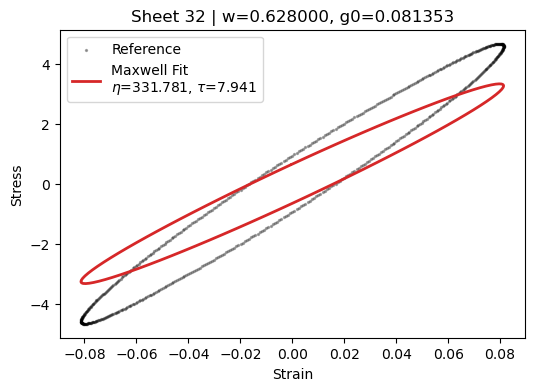

0.628rad - 0.2785584
Start Index (zero-crossing): 0


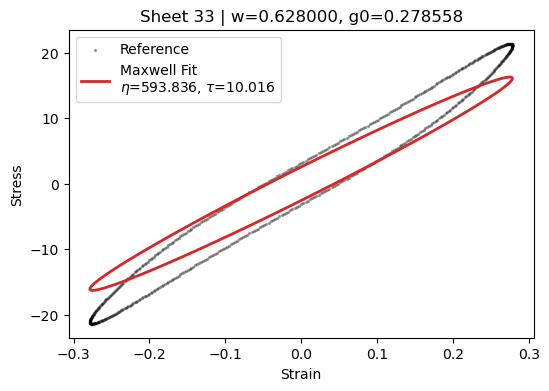

0.628rad - 0.7822665
Start Index (zero-crossing): 0


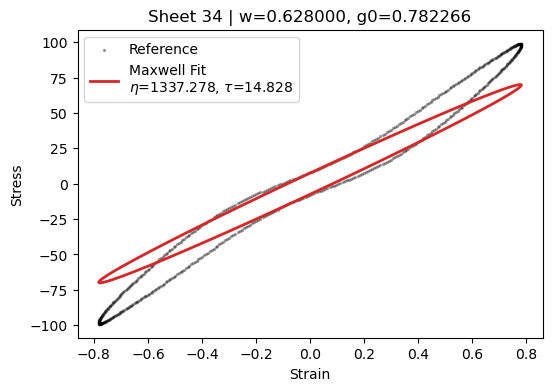

0.628rad - 0.0249694
Start Index (zero-crossing): 0


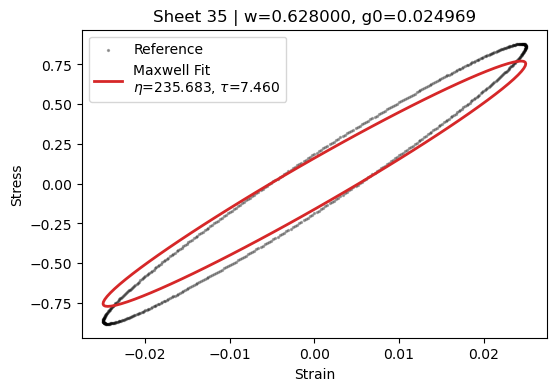

0.628rad - 0.088126
Start Index (zero-crossing): 0


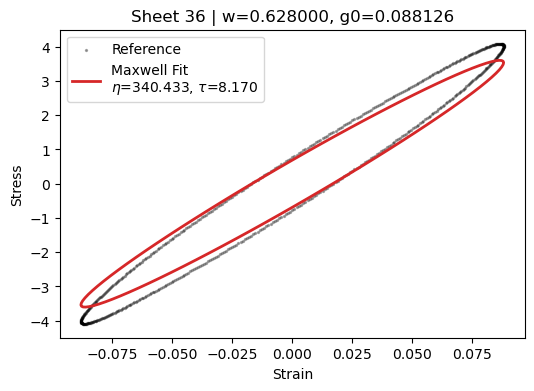

0.628rad - 0.2777553
Start Index (zero-crossing): 0


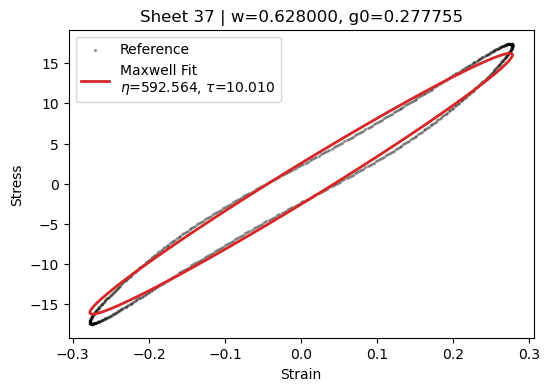

0.628rad - 0.7483737
Start Index (zero-crossing): 0


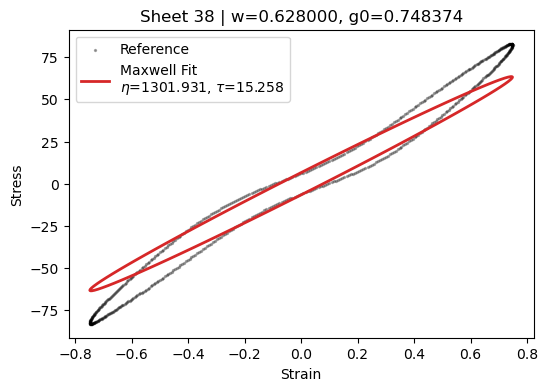

0.628rad - 0.0272475
Start Index (zero-crossing): 0


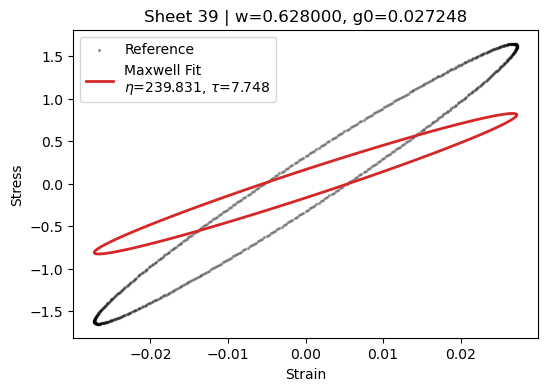

0.628rad - 0.0943436
Start Index (zero-crossing): 0


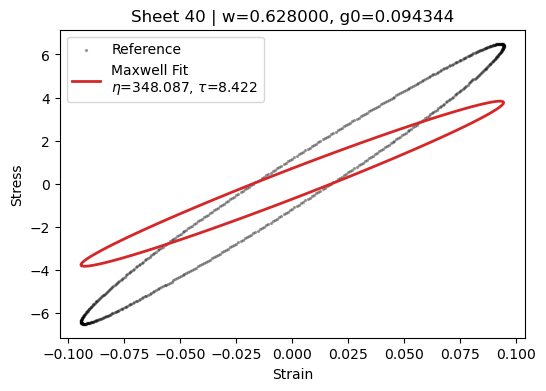

0.628rad - 0.2934034
Start Index (zero-crossing): 0


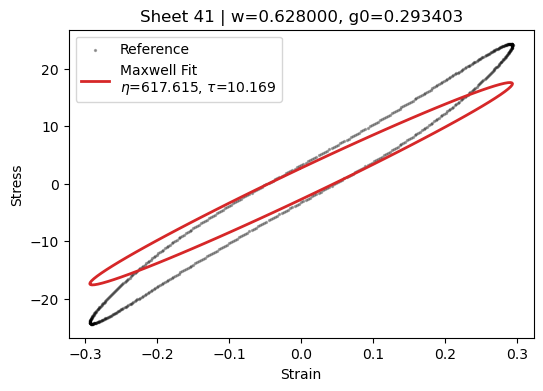

0.628rad - 0.8028754
Start Index (zero-crossing): 0


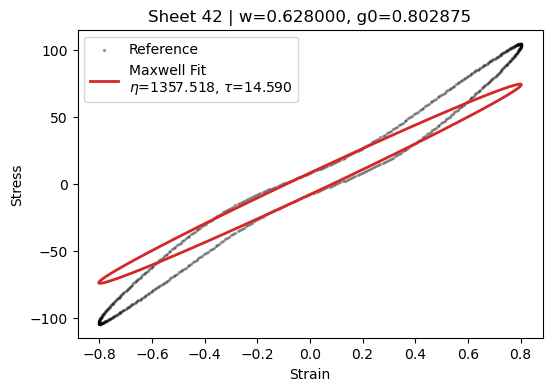

0.628rad - 0.0202411
Start Index (zero-crossing): 0


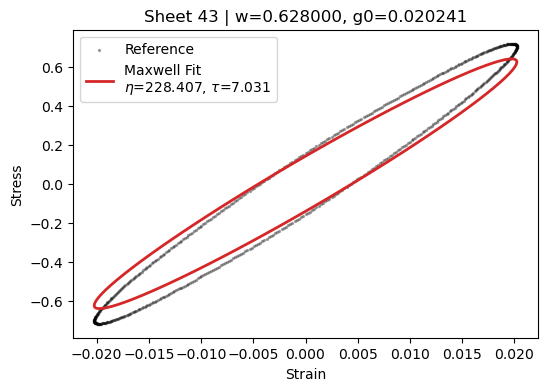

0.628rad - 0.0801314
Start Index (zero-crossing): 0


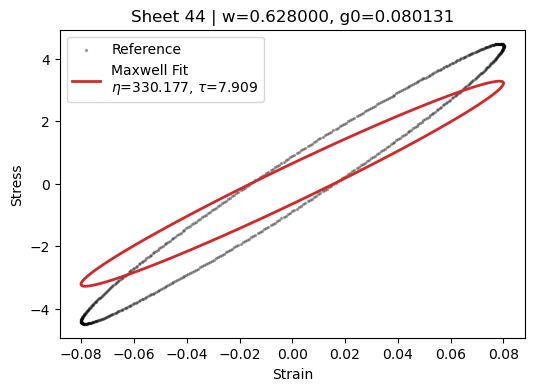

0.628rad - 0.2719648
Start Index (zero-crossing): 0


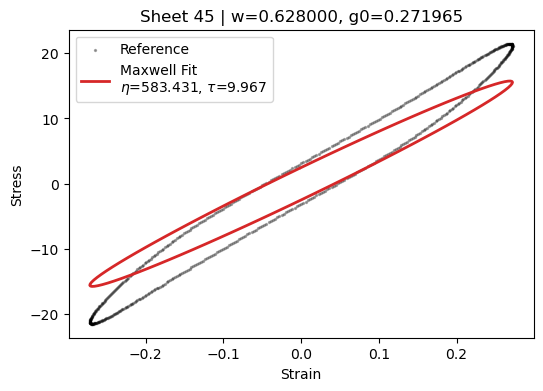

0.628rad - 0.7327955
Start Index (zero-crossing): 0


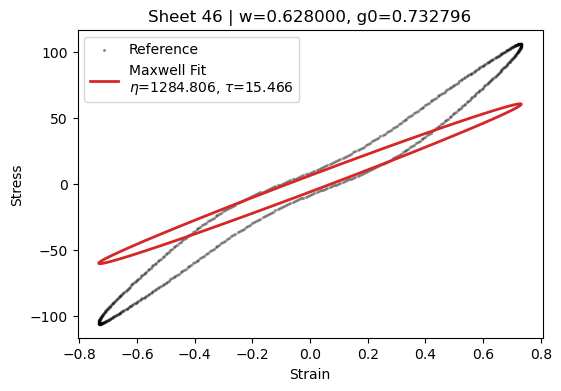

In [9]:
lf_set = indices
N_exp = int(3.*len(s_hf_sampled)/len(lf_set))  # Desired ratio of LF to HF data points, used to be 10

# Use lists, np.append is slow  
t_lf_list, g0_lf_list, w_lf_list, g_lf_list, gdot_lf_list, s_lf_list = [], [], [], [], [], []

for i in lf_set:
    t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(i)

    omega, g0 = X_fit_dict[i]
    y0 = y0_fit_dict[i]
    
    X_pred = np.reshape([omega, g0], (1,-1))
    X_pred_l = np.log(X_pred)
    eta_pred_l = gpr_eta.predict(X_pred_l)[0]
    tau_pred_l = gpr_tau.predict(X_pred_l)[0]

    eta_pred = np.exp(eta_pred_l)
    tau_pred = np.exp(tau_pred_l)
    # eta_pred, tau_pred = Y_fit_dict[i]  # TEST: Use per-sheet fitted values

    t_pred = np.linspace(min(t_test), max(t_test), N_exp)
    # Y_pred = fit_function(t_pred, eta_pred, tau_pred, y0, g0, omega)
    # TODO: build this into the fit_function
    # ---------------- FIX APPLIED HERE ----------------
    # Calculate Storage (G') and Loss (G'') Moduli analytically
    G_prime = (eta_pred * tau_pred * omega**2) / (1 + (tau_pred * omega)**2)
    G_double_prime = (eta_pred * omega) / (1 + (tau_pred * omega)**2)
    
    # Generate steady-state Stress directly (no odeint needed)
    Y_pred = g0 * (G_prime * np.sin(omega * t_pred) + G_double_prime * np.cos(omega * t_pred))
    # --------------------------------------------------
    
    g_pred = g0 * np.sin(omega * t_pred)
    gdot_pred = g0 * omega * np.cos(omega * t_pred)
    
    #LF generation
    g0_lf_list.extend(g0 * np.ones(N_exp))
    t_lf_list.extend(t_pred)
    w_lf_list.extend(omega * np.ones(N_exp))
    
    g_lf_list.extend(g_pred)
    gdot_lf_list.extend(gdot_pred)
    s_lf_list.extend(Y_pred)

    plt.figure(figsize=(6, 4))
    plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
    plt.scatter(st_test, s_test, label='Reference', s=2, color='k', alpha=0.3)
    plt.plot(g_pred, Y_pred, label=f'Maxwell Fit\n$\eta$={eta_pred:.3f}, $\\tau$={tau_pred:.3f}', linewidth=2, color='tab:red')
    plt.xlabel('Strain')
    plt.ylabel('Stress')
    plt.legend()
    plt.show()


### Exporting the Lo-Fi and Hi-Fi SAOS data
As mentioned above, and due to the time shift, the Hi-Fi data is also generated here based on the raw Hi-Fi data.

In [10]:
df_LF_raw = np.column_stack([g0_lf_list, t_lf_list,
                             w_lf_list, g_lf_list,
                             gdot_lf_list, s_lf_list])
df_LF = pd.DataFrame(df_LF_raw, columns = ['G0','Time', 'AngFreq', 'Strain', 'StrainRate', 'Stress'])
df_LF.to_excel("Data_LF_SAOS_pig_pstat.xlsx", index=False)
df_HF_raw = np.column_stack([g0_hf_sampled, t_hf_sampled,
                             w_hf_sampled, g_hf_sampled,
                             gdot_hf_sampled, s_hf_sampled])
df_HF = pd.DataFrame(df_HF_raw, columns = ['G0','Time', 'AngFreq', 'Strain', 'StrainRate', 'Stress'])
df_HF.to_excel("Data_HF_SAOS_pig_pstat.xlsx", index=False)

In [11]:
"""
MFNN LAOS Rheometry — Comprehensive Diagnostics
=================================================
Run this script AFTER Notebook 1 (LF generation) has been executed,
so that all variables (data, X_fit_dict, Y_fit_dict, y0_fit_dict,
gpr_eta, gpr_tau, etc.) are in scope.

Copy-paste each section into a notebook cell, or run the whole file
after exec-ing Notebook 1's namespace into globals().

Diagnostics covered:
  1. Maxwell fit quality per sheet (R², η/τ vs γ₀, overlay grid)
  2. GPR extrapolation quality (LOO CV, predicted vs actual)
  3. LF vs HF stress amplitude ratio
  4. Lissajous antisymmetry check
  5. Normalized input distribution divergence (LF vs HF)
  6. Per-sheet loss contribution (after MFNN training)
  7. pos_finder validation
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.integrate import odeint
from scipy.interpolate import interp1d
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.model_selection import LeaveOneOut
import warnings
warnings.filterwarnings("ignore")


# ═══════════════════════════════════════════════════════════════════
# HELPER: Ensure the Notebook-1 namespace is available
# ═══════════════════════════════════════════════════════════════════
# If running as a standalone script, you must first execute Notebook 1
# and then pass its namespace. In a notebook, just paste each section
# into cells after running Notebook 1.


# ═══════════════════════════════════════════════════════════════════
# DIAGNOSTIC 1 — Maxwell fit quality per sheet
# ═══════════════════════════════════════════════════════════════════
def diagnostic_1_maxwell_fit_quality(data, X_fit_dict, Y_fit_dict, y0_fit_dict, extractor, fit_function):
    """
    For every sheet:
      • Compute R² of the Maxwell ODE fit on the stress waveform
      • Plot η vs γ₀ and τ vs γ₀ on log-log axes
      • Overlay fitted Maxwell loop vs reference loop in a grid
    """
    n_sheets = len(data)
    
    etas = np.array([Y_fit_dict[i][0] for i in range(n_sheets)])
    taus = np.array([Y_fit_dict[i][1] for i in range(n_sheets)])
    g0s  = np.array([X_fit_dict[i][1] for i in range(n_sheets)])
    omegas = np.array([X_fit_dict[i][0] for i in range(n_sheets)])
    
    r2_scores = []
    stress_amp_ratios = []
    
    print("=" * 100)
    print("DIAGNOSTIC 1: Maxwell Fit Quality Per Sheet")
    print("=" * 100)
    print(f"{'Sheet':>5} {'γ₀':>10} {'ω':>8} {'η':>10} {'τ':>10} {'R²':>8} "
          f"{'|σ_fit|_max':>12} {'|σ_ref|_max':>12} {'Amp Ratio':>10} {'FLAG':>8}")
    print("-" * 100)
    
    for i in range(n_sheets):
        t_i, g0_i, w_i, s_i, st_i, sr_i = extractor(i)
        eta_i, tau_i = Y_fit_dict[i]
        omega_i, g0_val = X_fit_dict[i]
        y0_i = y0_fit_dict[i]
        
        # Compute Maxwell prediction via ODE
        s_i_np = s_i.values if hasattr(s_i, 'values') else np.array(s_i)
        t_i_np = t_i.values if hasattr(t_i, 'values') else np.array(t_i)
        
        try:
            s_pred = fit_function(t_i_np, eta_i, tau_i, y0_i, g0_val, omega_i)
            r2 = r2_score(s_i_np, s_pred.flatten())
        except Exception as e:
            r2 = float('nan')
            s_pred = np.zeros_like(s_i_np)
        
        s_fit_max = np.max(np.abs(s_pred))
        s_ref_max = np.max(np.abs(s_i_np))
        amp_ratio = s_fit_max / (s_ref_max + 1e-15)
        
        flag = ""
        if r2 < 0.5:
            flag += " LOW_R²"
        if amp_ratio > 2.0 or amp_ratio < 0.5:
            flag += " AMP_MISMATCH"
        if eta_i > 1000 or eta_i < 1e-4:
            flag += " η_EXTREME"
        if tau_i > 100 or tau_i < 1e-4:
            flag += " τ_EXTREME"
        
        r2_scores.append(r2)
        stress_amp_ratios.append(amp_ratio)
        
        print(f"{i:>5} {g0_val:>10.6f} {omega_i:>8.4f} {eta_i:>10.4f} {tau_i:>10.4f} {r2:>8.4f} "
              f"{s_fit_max:>12.4f} {s_ref_max:>12.4f} {amp_ratio:>10.3f} {flag}")
    
    # ── Plot η and τ vs γ₀ ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    ax.loglog(g0s, etas, 'ko-', markersize=6)
    for i in range(n_sheets):
        if r2_scores[i] < 0.5:
            ax.loglog(g0s[i], etas[i], 'rs', markersize=12, markerfacecolor='none', linewidth=2)
    ax.set_xlabel('γ₀ (strain amplitude)')
    ax.set_ylabel('η (viscosity)')
    ax.set_title('Fitted η vs γ₀ (red squares = R² < 0.5)')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.loglog(g0s, taus, 'ko-', markersize=6)
    for i in range(n_sheets):
        if r2_scores[i] < 0.5:
            ax.loglog(g0s[i], taus[i], 'rs', markersize=12, markerfacecolor='none', linewidth=2)
    ax.set_xlabel('γ₀ (strain amplitude)')
    ax.set_ylabel('τ (relaxation time)')
    ax.set_title('Fitted τ vs γ₀ (red squares = R² < 0.5)')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('diag1_eta_tau_vs_g0.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ── Grid of Lissajous overlays (Maxwell fit vs reference) ──
    n_cols = 5
    n_rows = int(np.ceil(n_sheets / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = axes.flatten()
    
    for i in range(n_sheets):
        ax = axes[i]
        t_i, g0_i, w_i, s_i, st_i, sr_i = extractor(i)
        eta_i, tau_i = Y_fit_dict[i]
        omega_i, g0_val = X_fit_dict[i]
        y0_i = y0_fit_dict[i]
        
        s_i_np = s_i.values if hasattr(s_i, 'values') else np.array(s_i)
        st_i_np = st_i.values if hasattr(st_i, 'values') else np.array(st_i)
        t_i_np = t_i.values if hasattr(t_i, 'values') else np.array(t_i)
        
        try:
            s_pred = fit_function(t_i_np, eta_i, tau_i, y0_i, g0_val, omega_i)
            g_pred = g0_val * np.sin(omega_i * t_i_np)
        except:
            s_pred = np.zeros_like(s_i_np)
            g_pred = np.zeros_like(s_i_np)
        
        ax.scatter(st_i_np, s_i_np, s=1, color='k', alpha=0.2, label='HF ref')
        ax.plot(g_pred, s_pred.flatten(), 'r-', linewidth=1.5, label='Maxwell')
        ax.set_title(f"#{i} γ₀={g0_val:.4f}\nR²={r2_scores[i]:.3f}", fontsize=8)
        ax.tick_params(labelsize=6)
        if i == 0:
            ax.legend(fontsize=6)
    
    for j in range(n_sheets, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('DIAGNOSTIC 1: Maxwell Fit vs Reference (All Sheets)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('diag1_maxwell_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return r2_scores, stress_amp_ratios


# ═══════════════════════════════════════════════════════════════════
# DIAGNOSTIC 2 — GPR extrapolation quality
# ═══════════════════════════════════════════════════════════════════
def diagnostic_2_gpr_quality(X_fit_dict, Y_fit_dict, gpr_eta, gpr_tau, X_log, Y_log):
    """
    LOO cross-validation on η and τ GPR.
    Plot predicted vs actual on log-log axes.
    Flag sheets where GPR relative error > 30%.
    """
    n_sheets = len(X_fit_dict)
    
    print("\n" + "=" * 100)
    print("DIAGNOSTIC 2: GPR Extrapolation Quality (LOO)")
    print("=" * 100)
    
    loo = LeaveOneOut()
    eta_pred_loo = np.zeros(n_sheets)
    tau_pred_loo = np.zeros(n_sheets)
    eta_std_loo = np.zeros(n_sheets)
    tau_std_loo = np.zeros(n_sheets)
    
    # Use the already-optimized kernels but refit in LOO
    for train_idx, test_idx in loo.split(X_log):
        gpr_eta_tmp = GaussianProcessRegressor(
            kernel=gpr_eta.kernel_, optimizer=None, normalize_y=True, random_state=8
        )
        gpr_tau_tmp = GaussianProcessRegressor(
            kernel=gpr_tau.kernel_, optimizer=None, normalize_y=True, random_state=8
        )
        
        gpr_eta_tmp.fit(X_log[train_idx], Y_log[train_idx, 0])
        gpr_tau_tmp.fit(X_log[train_idx], Y_log[train_idx, 1])
        
        mu_e, std_e = gpr_eta_tmp.predict(X_log[test_idx], return_std=True)
        mu_t, std_t = gpr_tau_tmp.predict(X_log[test_idx], return_std=True)
        
        eta_pred_loo[test_idx] = mu_e
        tau_pred_loo[test_idx] = mu_t
        eta_std_loo[test_idx] = std_e
        tau_std_loo[test_idx] = std_t
    
    # Convert back to original space
    eta_actual = np.exp(Y_log[:, 0])
    tau_actual = np.exp(Y_log[:, 1])
    eta_pred_orig = np.exp(eta_pred_loo)
    tau_pred_orig = np.exp(tau_pred_loo)
    
    g0s = np.array([X_fit_dict[i][1] for i in range(n_sheets)])
    
    print(f"\n{'Sheet':>5} {'γ₀':>10} {'η_actual':>10} {'η_pred':>10} {'η_err%':>8} {'η_GPR_σ':>8} "
          f"{'τ_actual':>10} {'τ_pred':>10} {'τ_err%':>8} {'τ_GPR_σ':>8} {'FLAG':>12}")
    print("-" * 115)
    
    for i in range(n_sheets):
        eta_err = 100 * abs(eta_pred_orig[i] - eta_actual[i]) / (eta_actual[i] + 1e-15)
        tau_err = 100 * abs(tau_pred_orig[i] - tau_actual[i]) / (tau_actual[i] + 1e-15)
        flag = ""
        if eta_err > 30:
            flag += " η>30%"
        if tau_err > 30:
            flag += " τ>30%"
        if eta_std_loo[i] > 0.5:
            flag += " η_UNCERT"
        if tau_std_loo[i] > 0.5:
            flag += " τ_UNCERT"
        
        print(f"{i:>5} {g0s[i]:>10.6f} {eta_actual[i]:>10.4f} {eta_pred_orig[i]:>10.4f} "
              f"{eta_err:>7.1f}% {eta_std_loo[i]:>8.4f} "
              f"{tau_actual[i]:>10.4f} {tau_pred_orig[i]:>10.4f} "
              f"{tau_err:>7.1f}% {tau_std_loo[i]:>8.4f} {flag}")
    
    # ── Predicted vs Actual plots ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, actual, pred, std, label in [
        (axes[0], eta_actual, eta_pred_orig, eta_std_loo, 'η'),
        (axes[1], tau_actual, tau_pred_orig, tau_std_loo, 'τ')
    ]:
        ax.loglog(actual, pred, 'ko', markersize=8)
        # Color by γ₀
        scatter = ax.scatter(actual, pred, c=np.log10(g0s), cmap='viridis', 
                           s=60, edgecolors='k', zorder=5)
        
        # Perfect prediction line
        lims = [min(actual.min(), pred.min()) * 0.5, max(actual.max(), pred.max()) * 2]
        ax.plot(lims, lims, 'k--', alpha=0.3, label='Perfect')
        ax.fill_between(lims, [l * 0.7 for l in lims], [l * 1.3 for l in lims], 
                        alpha=0.1, color='green', label='±30%')
        
        # Flag outliers
        for i in range(n_sheets):
            err = abs(pred[i] - actual[i]) / (actual[i] + 1e-15)
            if err > 0.3:
                ax.annotate(f'{i}', (actual[i], pred[i]), fontsize=8, color='red',
                           fontweight='bold', ha='left')
        
        ax.set_xlabel(f'Actual {label}')
        ax.set_ylabel(f'GPR LOO Predicted {label}')
        ax.set_title(f'{label}: Predicted vs Actual (LOO)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='log₁₀(γ₀)')
    
    plt.tight_layout()
    plt.savefig('diag2_gpr_loo.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ── GPR uncertainty vs γ₀ ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].semilogx(g0s, eta_std_loo, 'bo-')
    axes[0].axhline(0.5, color='r', linestyle='--', label='High uncertainty threshold')
    axes[0].set_xlabel('γ₀'); axes[0].set_ylabel('GPR σ (log-space)')
    axes[0].set_title('η GPR Uncertainty vs γ₀'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    
    axes[1].semilogx(g0s, tau_std_loo, 'bo-')
    axes[1].axhline(0.5, color='r', linestyle='--', label='High uncertainty threshold')
    axes[1].set_xlabel('γ₀'); axes[1].set_ylabel('GPR σ (log-space)')
    axes[1].set_title('τ GPR Uncertainty vs γ₀'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('diag2_gpr_uncertainty.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return eta_pred_orig, tau_pred_orig, eta_std_loo, tau_std_loo


# ═══════════════════════════════════════════════════════════════════
# DIAGNOSTIC 3 — LF vs HF stress amplitude ratio
# ═══════════════════════════════════════════════════════════════════
def diagnostic_3_lf_hf_amplitude_ratio(data, extractor, X_fit_dict, Y_fit_dict, y0_fit_dict,
                                        gpr_eta, gpr_tau):
    """
    For each sheet, compute ratio = max(|σ_LF|) / max(|σ_HF|).
    Flag sheets where ratio < 0.5 or > 2.0.
    """
    n_sheets = len(data)
    
    print("\n" + "=" * 100)
    print("DIAGNOSTIC 3: LF vs HF Stress Amplitude Ratio")
    print("=" * 100)
    
    ratios = []
    g0s = []
    
    print(f"\n{'Sheet':>5} {'γ₀':>10} {'ω':>8} {'η_GPR':>10} {'τ_GPR':>10} "
          f"{'|σ_LF|_max':>12} {'|σ_HF|_max':>12} {'Ratio':>8} {'FLAG':>20}")
    print("-" * 110)
    
    for i in range(n_sheets):
        t_i, g0_i, w_i, s_i, st_i, sr_i = extractor(i)
        omega_i, g0_val = X_fit_dict[i]
        y0_i = y0_fit_dict[i]
        
        # GPR-predicted η, τ
        X_pred_l = np.log(np.reshape([omega_i, g0_val], (1, -1)))
        eta_gpr = np.exp(gpr_eta.predict(X_pred_l)[0])
        tau_gpr = np.exp(gpr_tau.predict(X_pred_l)[0])
        
        # Analytical steady-state Maxwell LF stress
        G_prime = (eta_gpr * tau_gpr * omega_i**2) / (1 + (tau_gpr * omega_i)**2)
        G_double_prime = (eta_gpr * omega_i) / (1 + (tau_gpr * omega_i)**2)
        
        t_np = t_i.values if hasattr(t_i, 'values') else np.array(t_i)
        s_lf = g0_val * (G_prime * np.sin(omega_i * t_np) + G_double_prime * np.cos(omega_i * t_np))
        
        s_hf_np = s_i.values if hasattr(s_i, 'values') else np.array(s_i)
        
        lf_max = np.max(np.abs(s_lf))
        hf_max = np.max(np.abs(s_hf_np))
        ratio = lf_max / (hf_max + 1e-15)
        
        flag = ""
        if ratio > 2.0:
            flag = "⚠ LF >> HF (TOO LARGE)"
        elif ratio < 0.5:
            flag = "⚠ LF << HF (TOO SMALL)"
        elif ratio > 1.5:
            flag = "~ LF somewhat large"
        elif ratio < 0.7:
            flag = "~ LF somewhat small"
        
        ratios.append(ratio)
        g0s.append(g0_val)
        
        print(f"{i:>5} {g0_val:>10.6f} {omega_i:>8.4f} {eta_gpr:>10.4f} {tau_gpr:>10.4f} "
              f"{lf_max:>12.4f} {hf_max:>12.4f} {ratio:>8.3f} {flag}")
    
    # ── Plot ratio vs γ₀ ──
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.semilogx(g0s, ratios, 'ko-', markersize=8)
    ax.axhline(1.0, color='green', linestyle='-', alpha=0.5, label='Perfect (1.0)')
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Lower bound (0.5)')
    ax.axhline(2.0, color='red', linestyle='--', alpha=0.5, label='Upper bound (2.0)')
    ax.fill_between([min(g0s) * 0.5, max(g0s) * 2], 0.5, 2.0, alpha=0.05, color='green')
    
    for i in range(n_sheets):
        if ratios[i] > 2.0 or ratios[i] < 0.5:
            ax.annotate(f'{i}', (g0s[i], ratios[i]), fontsize=9, color='red', fontweight='bold')
    
    ax.set_xlabel('γ₀ (strain amplitude)')
    ax.set_ylabel('max|σ_LF| / max|σ_HF|')
    ax.set_title('DIAGNOSTIC 3: LF/HF Stress Amplitude Ratio vs γ₀')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, max(ratios) * 1.2)
    plt.tight_layout()
    plt.savefig('diag3_lf_hf_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return ratios


# ═══════════════════════════════════════════════════════════════════
# DIAGNOSTIC 4 — Lissajous antisymmetry check
# ═══════════════════════════════════════════════════════════════════
def diagnostic_4_antisymmetry(data, extractor):
    """
    For each sheet's reference data, compute the antisymmetry residual:
      R = σ(γ) + σ(-γ) after interpolating to a regular grid.
    Report mean|R| normalized by stress amplitude.
    """
    n_sheets = len(data)
    
    print("\n" + "=" * 100)
    print("DIAGNOSTIC 4: Lissajous Antisymmetry Check")
    print("=" * 100)
    print("  Point-antisymmetry: σ(-γ,-γ̇) = -σ(γ,γ̇)")
    print("  Residual R = [σ(γ,γ̇) + σ(-γ,-γ̇)] / (2·σ_amp)")
    print("  R ≈ 0 means perfectly antisymmetric")
    print()
    
    residuals = []
    g0s = []
    
    print(f"{'Sheet':>5} {'γ₀':>10} {'mean|R|':>10} {'max|R|':>10} {'σ_amp':>10} {'NOTE':>20}")
    print("-" * 75)
    
    for i in range(n_sheets):
        t_i, g0_i, w_i, s_i, st_i, sr_i = extractor(i)
        
        s_np = s_i.values if hasattr(s_i, 'values') else np.array(s_i)
        st_np = st_i.values if hasattr(st_i, 'values') else np.array(st_i)
        sr_np = sr_i.values if hasattr(sr_i, 'values') else np.array(sr_i)
        g0_val = np.unique(g0_i)[0] if hasattr(g0_i, 'values') else np.unique(g0_i)[0]
        
        s_amp = (np.max(s_np) - np.min(s_np)) / 2.0
        
        # Check antisymmetry by pairing (γ, γ̇, σ) with (-γ, -γ̇)
        # For oscillatory data, if γ(t) = γ₀ sin(ωt), then γ(t+π/ω) = -γ(t)
        # So we compare σ(t) with -σ(t + T/2)
        n = len(s_np)
        half = n // 2
        
        if half > 10:
            # Compare first half with negated second half
            len_compare = min(half, n - half)
            R = s_np[:len_compare] + s_np[half:half + len_compare]
            R_norm = R / (2.0 * s_amp + 1e-15)
            mean_R = np.mean(np.abs(R_norm))
            max_R = np.max(np.abs(R_norm))
        else:
            mean_R = float('nan')
            max_R = float('nan')
        
        note = ""
        if mean_R > 0.2:
            note = "⚠ SIGNIFICANT ASYMMETRY"
        elif mean_R > 0.1:
            note = "~ moderate asymmetry"
        
        residuals.append(mean_R)
        g0s.append(g0_val)
        
        print(f"{i:>5} {g0_val:>10.6f} {mean_R:>10.4f} {max_R:>10.4f} {s_amp:>10.4f} {note}")
    
    # ── Plot ──
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.semilogx(g0s, residuals, 'ko-', markersize=8)
    ax.axhline(0.1, color='orange', linestyle='--', label='Moderate threshold')
    ax.axhline(0.2, color='red', linestyle='--', label='High threshold')
    ax.set_xlabel('γ₀')
    ax.set_ylabel('Mean |R| (normalized antisymmetry residual)')
    ax.set_title('DIAGNOSTIC 4: Lissajous Antisymmetry Residual')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('diag4_antisymmetry.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return residuals


# ═══════════════════════════════════════════════════════════════════
# DIAGNOSTIC 5 — Normalized input distribution (LF vs HF)
# ═══════════════════════════════════════════════════════════════════
def diagnostic_5_input_distributions(X_data_LF, X_data_HF, y_data_LF, y_data_HF, scaler_X, scaler_y):
    """
    After applying scaler_X, plot histograms of each normalized feature
    for LF and HF data overlaid. Flag features where distributions diverge.
    
    NOTE: Pass the ALREADY-NORMALIZED tensors (as produced by Notebook 2).
    """
    print("\n" + "=" * 100)
    print("DIAGNOSTIC 5: Normalized Input Distribution (LF vs HF)")
    print("=" * 100)
    
    # Convert to numpy
    X_lf = X_data_LF.numpy() if hasattr(X_data_LF, 'numpy') else np.array(X_data_LF)
    X_hf = X_data_HF.numpy() if hasattr(X_data_HF, 'numpy') else np.array(X_data_HF)
    y_lf = y_data_LF.numpy() if hasattr(y_data_LF, 'numpy') else np.array(y_data_LF)
    y_hf = y_data_HF.numpy() if hasattr(y_data_HF, 'numpy') else np.array(y_data_HF)
    
    feature_names = ['Strain (norm)', 'Strain Rate (norm)', 'ω (norm)', 'γ₀ (norm)']
    n_features = X_lf.shape[1]
    
    fig, axes = plt.subplots(1, n_features + 1, figsize=(4 * (n_features + 1), 4))
    
    for j in range(n_features):
        ax = axes[j]
        ax.hist(X_hf[:, j], bins=50, alpha=0.5, label='HF', color='black', density=True)
        ax.hist(X_lf[:, j], bins=50, alpha=0.5, label='LF', color='blue', density=True)
        ax.set_title(feature_names[j] if j < len(feature_names) else f'Feature {j}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Compute KL-like divergence (simple: difference of means and stds)
        mean_diff = abs(np.mean(X_lf[:, j]) - np.mean(X_hf[:, j]))
        std_ratio = np.std(X_lf[:, j]) / (np.std(X_hf[:, j]) + 1e-10)
        print(f"  {feature_names[j] if j < len(feature_names) else f'Feature {j}':>25}: "
              f"mean_diff={mean_diff:.4f}, std_ratio={std_ratio:.4f}"
              f"{'  ⚠ DIVERGENT' if mean_diff > 0.5 or std_ratio > 2.0 or std_ratio < 0.5 else ''}")
    
    # Output (stress)
    ax = axes[-1]
    ax.hist(y_hf.flatten(), bins=50, alpha=0.5, label='HF', color='black', density=True)
    ax.hist(y_lf.flatten(), bins=50, alpha=0.5, label='LF', color='blue', density=True)
    ax.set_title('Stress (norm)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    mean_diff_y = abs(np.mean(y_lf) - np.mean(y_hf))
    std_ratio_y = np.std(y_lf) / (np.std(y_hf) + 1e-10)
    print(f"  {'Stress (norm)':>25}: mean_diff={mean_diff_y:.4f}, std_ratio={std_ratio_y:.4f}"
          f"{'  ⚠ DIVERGENT' if mean_diff_y > 0.5 or std_ratio_y > 2.0 or std_ratio_y < 0.5 else ''}")
    
    plt.suptitle('DIAGNOSTIC 5: Normalized Feature Distributions (LF=blue, HF=black)', fontsize=12)
    plt.tight_layout()
    plt.savefig('diag5_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ── Scatter: γ₀ feature distribution ──
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(X_hf[:, 0], X_hf[:, 1], s=1, alpha=0.1, c='k', label='HF')
    axes[0].scatter(X_lf[:, 0], X_lf[:, 1], s=1, alpha=0.1, c='b', label='LF')
    axes[0].set_xlabel('Strain (norm)'); axes[0].set_ylabel('Strain Rate (norm)')
    axes[0].set_title('Input space: Strain vs Strain Rate')
    axes[0].legend(markerscale=10)
    
    axes[1].scatter(X_hf[:, 2], X_hf[:, 3], s=3, alpha=0.3, c='k', label='HF')
    axes[1].scatter(X_lf[:, 2], X_lf[:, 3], s=3, alpha=0.3, c='b', label='LF')
    axes[1].set_xlabel('ω (norm)'); axes[1].set_ylabel('γ₀ (norm)')
    axes[1].set_title('Input space: ω vs γ₀')
    axes[1].legend(markerscale=5)
    
    plt.tight_layout()
    plt.savefig('diag5_input_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()


# ═══════════════════════════════════════════════════════════════════
# DIAGNOSTIC 6 — Per-sheet loss contribution (after MFNN training)
# ═══════════════════════════════════════════════════════════════════
def diagnostic_6_per_sheet_loss(data, extractor, model_LF, model_HF_nl, model_HF_l,
                                 scaler_X, scaler_y, normalize_data):
    """
    After training, compute Loss_LF, Loss_HF, Loss_total per sheet.
    Identifies which sheets are well-learned vs ignored.
    
    Pass the trained models and the normalize_data function from Notebook 2.
    """
    import tensorflow as tf
    
    n_sheets = len(data)
    
    print("\n" + "=" * 100)
    print("DIAGNOSTIC 6: Per-Sheet Loss Contribution (Post-Training)")
    print("=" * 100)
    
    print(f"\n{'Sheet':>5} {'γ₀':>10} {'MSE_MF':>12} {'MSE_LF':>12} {'R²_MF':>8} {'R²_LF':>8} "
          f"{'σ_amp':>10} {'MSE/σ²':>10} {'FLAG':>15}")
    print("-" * 105)
    
    mse_mf_list = []
    mse_lf_list = []
    r2_mf_list = []
    g0s = []
    
    for i in range(n_sheets):
        try:
            t_i, g0_i, w_i, s_i, st_i, sr_i = extractor(i)
            g0_val = np.unique(g0_i)[0] if hasattr(g0_i, 'unique') else np.unique(g0_i)[0]
            omega_val = np.unique(w_i)[0] if hasattr(w_i, 'unique') else np.unique(w_i)[0]
            
            s_np = s_i.values if hasattr(s_i, 'values') else np.array(s_i)
            st_np = st_i.values if hasattr(st_i, 'values') else np.array(st_i)
            sr_np = sr_i.values if hasattr(sr_i, 'values') else np.array(sr_i)
            w_np = w_i.values if hasattr(w_i, 'values') else np.array(w_i)
            g0_np = g0_i.values if hasattr(g0_i, 'values') else np.array(g0_i)
            
            X_test = np.column_stack([st_np, sr_np, w_np, g0_np])
            y_test = np.column_stack([s_np])
            
            X_test_norm, y_test_norm = normalize_data(X_test, y_test, scaler_X, scaler_y)
            
            y_LF_pred = model_LF(X_test_norm)
            X_MF = np.column_stack((X_test_norm, y_LF_pred))
            y_MF_pred = model_HF_nl(X_MF) + model_HF_l(X_MF)
            
            y_LF_denorm = scaler_y.inverse_transform(y_LF_pred.numpy())
            y_MF_denorm = scaler_y.inverse_transform(y_MF_pred.numpy())
            
            mse_mf = np.mean((s_np.flatten() - y_MF_denorm.flatten()) ** 2)
            mse_lf = np.mean((s_np.flatten() - y_LF_denorm.flatten()) ** 2)
            
            s_amp = (np.max(s_np) - np.min(s_np)) / 2.0
            mse_normalized = mse_mf / (s_amp**2 + 1e-15)
            
            r2_mf = r2_score(s_np.flatten(), y_MF_denorm.flatten())
            r2_lf = r2_score(s_np.flatten(), y_LF_denorm.flatten())
            
            flag = ""
            if r2_mf < 0.8:
                flag += " LOW_R²_MF"
            if mse_normalized > 0.1:
                flag += " HIGH_NORM_MSE"
            if r2_lf < 0:
                flag += " LF_WORSE_MEAN"
            
            mse_mf_list.append(mse_mf)
            mse_lf_list.append(mse_lf)
            r2_mf_list.append(r2_mf)
            g0s.append(g0_val)
            
            print(f"{i:>5} {g0_val:>10.6f} {mse_mf:>12.6f} {mse_lf:>12.6f} {r2_mf:>8.4f} {r2_lf:>8.4f} "
                  f"{s_amp:>10.4f} {mse_normalized:>10.4f} {flag}")
        except Exception as e:
            print(f"{i:>5} ERROR: {e}")
            mse_mf_list.append(float('nan'))
            mse_lf_list.append(float('nan'))
            r2_mf_list.append(float('nan'))
            g0s.append(float('nan'))
    
    # ── Plot R² vs γ₀ ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    ax.semilogx(g0s, r2_mf_list, 'ro-', label='R² (MFNN)', markersize=8)
    ax.semilogx(g0s, [r2_score(
        (lambda s: s.values if hasattr(s, 'values') else np.array(s))(extractor(i)[3]).flatten(),
        scaler_y.inverse_transform(model_LF(normalize_data(
            np.column_stack([(lambda x: x.values if hasattr(x, 'values') else np.array(x))(extractor(i)[4]),
                           (lambda x: x.values if hasattr(x, 'values') else np.array(x))(extractor(i)[5]),
                           (lambda x: x.values if hasattr(x, 'values') else np.array(x))(extractor(i)[2]),
                           (lambda x: x.values if hasattr(x, 'values') else np.array(x))(extractor(i)[1])]),
            np.column_stack([(lambda x: x.values if hasattr(x, 'values') else np.array(x))(extractor(i)[3])]),
            scaler_X, scaler_y)[0]).numpy()).flatten()
    ) for i in range(n_sheets)], 'b--', label='R² (LF only)', markersize=5, alpha=0.7)
    ax.axhline(0.9, color='green', linestyle=':', alpha=0.5)
    ax.axhline(0.0, color='red', linestyle=':', alpha=0.5)
    ax.set_xlabel('γ₀'); ax.set_ylabel('R²')
    ax.set_title('DIAGNOSTIC 6: R² vs γ₀ (per sheet)')
    ax.legend(); ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.loglog(g0s, mse_mf_list, 'ro-', label='MSE (MFNN)', markersize=8)
    ax.loglog(g0s, mse_lf_list, 'b--', label='MSE (LF only)', markersize=5, alpha=0.7)
    ax.set_xlabel('γ₀'); ax.set_ylabel('MSE (original scale)')
    ax.set_title('DIAGNOSTIC 6: MSE vs γ₀ (per sheet)')
    ax.legend(); ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('diag6_per_sheet_loss.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return mse_mf_list, r2_mf_list


# ═══════════════════════════════════════════════════════════════════
# DIAGNOSTIC 7 — pos_finder validation
# ═══════════════════════════════════════════════════════════════════
def diagnostic_7_pos_finder(data, pos_finder):
    """
    For 5+ sheets, plot the raw strain signal and mark the detected
    zero-crossing index. Visual check for correctness.
    """
    n_sheets = len(data)
    check_indices = list(range(min(8, n_sheets)))  # Check first 8 sheets
    
    print("\n" + "=" * 100)
    print("DIAGNOSTIC 7: pos_finder Validation")
    print("=" * 100)
    
    n_cols = 4
    n_rows = int(np.ceil(len(check_indices) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes = axes.flatten()
    
    for plot_idx, i in enumerate(check_indices):
        ax = axes[plot_idx]
        df_sheet = data[i][1].dropna()
        strain = df_sheet['Strain'].to_numpy()
        time_raw = df_sheet['Step time'].to_numpy()
        
        idx = pos_finder(strain)
        
        ax.plot(time_raw, strain, 'k-', linewidth=0.5, alpha=0.7)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(time_raw[idx], color='red', linestyle='-', linewidth=2, alpha=0.7)
        ax.plot(time_raw[idx], strain[idx], 'ro', markersize=10, zorder=5)
        
        g0_val = df_sheet['Oscillation strain'].iloc[0]
        ax.set_title(f'Sheet {i} (γ₀={g0_val:.4f})\nidx={idx}, t={time_raw[idx]:.3f}, γ={strain[idx]:.5f}',
                     fontsize=8)
        ax.tick_params(labelsize=7)
        
        # Print info
        print(f"  Sheet {i}: idx={idx}, t₀={time_raw[idx]:.4f}, γ(t₀)={strain[idx]:.6f}, "
              f"γ₀={g0_val:.6f}")
        if abs(strain[idx]) > 0.1 * g0_val:
            print(f"    ⚠ WARNING: Zero-crossing strain |{strain[idx]:.6f}| > 10% of γ₀={g0_val:.6f}")
    
    for j in range(len(check_indices), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('DIAGNOSTIC 7: pos_finder Zero-Crossing Detection', fontsize=13)
    plt.tight_layout()
    plt.savefig('diag7_pos_finder.png', dpi=150, bbox_inches='tight')
    plt.show()


# ═══════════════════════════════════════════════════════════════════
# BONUS DIAGNOSTIC — Stress scale analysis
# ═══════════════════════════════════════════════════════════════════
def diagnostic_bonus_stress_scaling(data, extractor):
    """
    Check how stress amplitude scales with γ₀.
    In linear VE regime: σ_amp ∝ γ₀
    In nonlinear regime: σ_amp may saturate or show different scaling.
    This helps diagnose whether StandardScaler is appropriate.
    """
    n_sheets = len(data)
    
    print("\n" + "=" * 100)
    print("BONUS DIAGNOSTIC: Stress Amplitude Scaling with γ₀")
    print("=" * 100)
    
    g0s = []
    s_amps = []
    s_amps_over_g0 = []
    
    for i in range(n_sheets):
        t_i, g0_i, w_i, s_i, st_i, sr_i = extractor(i)
        g0_val = np.unique(g0_i)[0] if hasattr(g0_i, 'unique') else np.unique(g0_i)[0]
        s_np = s_i.values if hasattr(s_i, 'values') else np.array(s_i)
        s_amp = (np.max(s_np) - np.min(s_np)) / 2.0
        
        g0s.append(g0_val)
        s_amps.append(s_amp)
        s_amps_over_g0.append(s_amp / g0_val)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    ax = axes[0]
    ax.loglog(g0s, s_amps, 'ko-', markersize=8)
    # Plot linear reference: σ ∝ γ₀
    g0_sort = np.sort(g0s)
    ax.loglog(g0_sort, g0_sort * (s_amps[0] / g0s[0]), 'r--', alpha=0.5, label='σ ∝ γ₀ (linear VE)')
    ax.set_xlabel('γ₀')
    ax.set_ylabel('σ_amplitude')
    ax.set_title('Stress Amplitude vs γ₀')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.semilogx(g0s, s_amps_over_g0, 'ko-', markersize=8)
    ax.set_xlabel('γ₀')
    ax.set_ylabel('σ_amp / γ₀ ≈ |G*|')
    ax.set_title('Normalized Stress Amplitude (≈ |G*|) vs γ₀\n(Should be flat in linear regime)')
    ax.grid(True, alpha=0.3)
    
    ax = axes[2]
    # How many orders of magnitude does stress span?
    s_ratio = max(s_amps) / min(s_amps)
    g_ratio = max(g0s) / min(g0s)
    ax.bar(['γ₀ range', 'σ range'], [np.log10(g_ratio), np.log10(s_ratio)], color=['blue', 'red'])
    ax.set_ylabel('Orders of magnitude (log₁₀)')
    ax.set_title(f'Dynamic Range\nγ₀: {g_ratio:.0f}x, σ: {s_ratio:.0f}x')
    ax.grid(True, alpha=0.3)
    
    print(f"\n  γ₀ range: {min(g0s):.6f} → {max(g0s):.6f} ({g_ratio:.0f}x)")
    print(f"  σ  range: {min(s_amps):.6f} → {max(s_amps):.6f} ({s_ratio:.0f}x)")
    print(f"  σ/γ₀ range: {min(s_amps_over_g0):.2f} → {max(s_amps_over_g0):.2f}")
    
    if s_ratio > 100:
        print("\n  ⚠ CRITICAL: Stress spans >2 orders of magnitude!")
        print("  StandardScaler will be dominated by high-amplitude sheets.")
        print("  Low-amplitude data is effectively invisible to MSE loss.")
        print("  → STRONGLY recommend per-amplitude normalization or log-scaling.")
    
    plt.tight_layout()
    plt.savefig('diag_bonus_scaling.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return g0s, s_amps, s_amps_over_g0


# ═══════════════════════════════════════════════════════════════════
# MASTER RUNNER
# ═══════════════════════════════════════════════════════════════════
def run_all_diagnostics_notebook1(data, X_fit_dict, Y_fit_dict, y0_fit_dict,
                                   gpr_eta, gpr_tau, X_log, Y_log,
                                   extractor, fit_function, pos_finder):
    """
    Run all diagnostics that can be run after Notebook 1.
    Call this from a notebook cell after executing Notebook 1.
    """
    print("╔" + "═" * 78 + "╗")
    print("║  MFNN LAOS DIAGNOSTICS — NOTEBOOK 1 (LF Generation Layer)                  ║")
    print("╚" + "═" * 78 + "╝")
    
    r2_scores, amp_ratios_fit = diagnostic_1_maxwell_fit_quality(
        data, X_fit_dict, Y_fit_dict, y0_fit_dict, extractor, fit_function)
    
    eta_pred, tau_pred, eta_std, tau_std = diagnostic_2_gpr_quality(
        X_fit_dict, Y_fit_dict, gpr_eta, gpr_tau, X_log, Y_log)
    
    lf_hf_ratios = diagnostic_3_lf_hf_amplitude_ratio(
        data, extractor, X_fit_dict, Y_fit_dict, y0_fit_dict, gpr_eta, gpr_tau)
    
    antisymmetry = diagnostic_4_antisymmetry(data, extractor)
    
    diagnostic_7_pos_finder(data, pos_finder)
    
    g0s, s_amps, s_over_g0 = diagnostic_bonus_stress_scaling(data, extractor)
    
    # ── Summary ──
    print("\n" + "╔" + "═" * 78 + "╗")
    print("║  SUMMARY OF FINDINGS                                                        ║")
    print("╚" + "═" * 78 + "╝")
    
    n = len(data)
    bad_maxwell = sum(1 for r in r2_scores if r < 0.5)
    bad_gpr = sum(1 for i in range(n) if eta_std[i] > 0.5 or tau_std[i] > 0.5)
    bad_ratio = sum(1 for r in lf_hf_ratios if r < 0.5 or r > 2.0)
    bad_sym = sum(1 for r in antisymmetry if r > 0.2)
    
    print(f"\n  Sheets with poor Maxwell fit (R² < 0.5):     {bad_maxwell}/{n}")
    print(f"  Sheets with high GPR uncertainty (σ > 0.5):  {bad_gpr}/{n}")
    print(f"  Sheets with LF/HF amp ratio outside [0.5,2]: {bad_ratio}/{n}")
    print(f"  Sheets with significant asymmetry (R > 0.2): {bad_sym}/{n}")
    print(f"  Stress dynamic range:                        {max(s_amps)/min(s_amps):.0f}x")
    
    return {
        'r2_scores': r2_scores,
        'lf_hf_ratios': lf_hf_ratios,
        'antisymmetry': antisymmetry,
        'eta_pred': eta_pred, 'tau_pred': tau_pred,
        'eta_std': eta_std, 'tau_std': tau_std,
        'g0s': g0s, 's_amps': s_amps
    }


def run_all_diagnostics_notebook2(data, extractor, model_LF, model_HF_nl, model_HF_l,
                                   scaler_X, scaler_y, normalize_data,
                                   X_data_LF, X_data_HF, y_data_LF, y_data_HF):
    """
    Run diagnostics that require Notebook 2's trained models.
    Call this from a notebook cell after training in Notebook 2.
    """
    print("╔" + "═" * 78 + "╗")
    print("║  MFNN LAOS DIAGNOSTICS — NOTEBOOK 2 (Post-Training)                         ║")
    print("╚" + "═" * 78 + "╝")
    
    diagnostic_5_input_distributions(X_data_LF, X_data_HF, y_data_LF, y_data_HF,
                                      scaler_X, scaler_y)
    
    mse_list, r2_list = diagnostic_6_per_sheet_loss(
        data, extractor, model_LF, model_HF_nl, model_HF_l,
        scaler_X, scaler_y, normalize_data)
    
    return {'mse_per_sheet': mse_list, 'r2_per_sheet': r2_list}

In [12]:
# run_all_diagnostics_notebook1(data, X_fit_dict, Y_fit_dict, y0_fit_dict,
#                                    gpr_eta, gpr_tau, X_log, Y_log,
#                                    extractor, fit_function, pos_finder)